# Retail Sales Analysis and Forecasting

## Project Overview

This project analyzes historical retail sales data and develops a machine learning model to forecast future sales.

The dataset contains information on daily sales across multiple stores and product families, together with promotional activity, store characteristics, holidays, transactions, and oil prices.

The main objective is to understand the factors associated with retail sales and determine whether historical sales patterns can be used to predict future demand.

### Main Research Question

Can historical sales patterns, promotions, store characteristics, holidays, transactions, and oil prices be used to accurately predict future retail sales?

### Project Objectives

1. Understand the structure and quality of the dataset.
2. Explore sales patterns across time, stores, and product families.
3. Investigate the relationship between sales and other variables.
4. Engineer features that capture temporal sales behaviour.
5. Develop a machine learning forecasting model.
6. Evaluate the model using RMSLE.
7. Generate forecasts for the future test period.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import zipfile
import os

# Location of the ZIP file
zip_path = r"C:\Users\wangu\Downloads\store-sales-time-series-forecasting.zip"

# Folder where we will extract the dataset
extract_path = r"C:\Users\wangu\Downloads\store_sales"

# Extract the dataset only if the folder does not already exist
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

# Display the extracted files
os.listdir(extract_path)

Dataset already extracted.


['holidays_events.csv',
 'oil.csv',
 'sample_submission.csv',
 'stores.csv',
 'test.csv',
 'train.csv',
 'transactions.csv']

In [3]:
# Load the datasets
train = pd.read_csv(os.path.join(extract_path, "train.csv"))
test = pd.read_csv(os.path.join(extract_path, "test.csv"))
stores = pd.read_csv(os.path.join(extract_path, "stores.csv"))
transactions = pd.read_csv(os.path.join(extract_path, "transactions.csv"))
oil = pd.read_csv(os.path.join(extract_path, "oil.csv"))
holidays = pd.read_csv(os.path.join(extract_path, "holidays_events.csv"))

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Stores:", stores.shape)
print("Transactions:", transactions.shape)
print("Oil:", oil.shape)
print("Holidays:", holidays.shape)

Train: (3000888, 6)
Test: (28512, 5)
Stores: (54, 5)
Transactions: (83488, 3)
Oil: (1218, 2)
Holidays: (350, 6)


In [5]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [7]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [8]:
train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [9]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [10]:
train.duplicated().sum()

np.int64(0)

In [11]:
print("Start date:", train["date"].min())
print("End date:", train["date"].max())

Start date: 2013-01-01
End date: 2017-08-15


In [12]:
print("Number of unique stores:", train["store_nbr"].nunique())
print("Number of unique product families:", train["family"].nunique())

Number of unique stores: 54
Number of unique product families: 33


In [13]:
# Display all product families
train["family"].unique()

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

In [14]:
# Convert date from object/text to datetime
train["date"] = pd.to_datetime(train["date"])

# Check the data type
train["date"].dtype

dtype('<M8[ns]')


The date column was converted from text into a datetime format. This allows individual components such as year, month, day, and day of the week to be extracted later.

Converting the date is important because retail sales are strongly influenced by time-related patterns such as seasonality, weekends, holidays, and long-term trends.

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [16]:
# Basic statistics for sales
train["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64


The sales variable is highly right-skewed. The mean sales value of 357.78 is substantially higher than the median of 11, indicating that a relatively small number of observations have very high sales values.

At least 25% of the observations have zero sales, while the maximum recorded value is 124,717. This large range indicates substantial variation in demand across stores, product families, and dates.

The extreme values were not automatically removed because they may represent genuine high-demand periods rather than data errors. Instead, the effect of the skewed distribution is considered during modelling and evaluation.

In [17]:
# Basic statistics for promotions
train["onpromotion"].describe()

count    3.000888e+06
mean     2.602770e+00
std      1.221888e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.410000e+02
Name: onpromotion, dtype: float64

In [18]:
# Calculate total sales for each day
daily_sales = train.groupby("date")["sales"].sum().reset_index()

# Display the first few results
daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


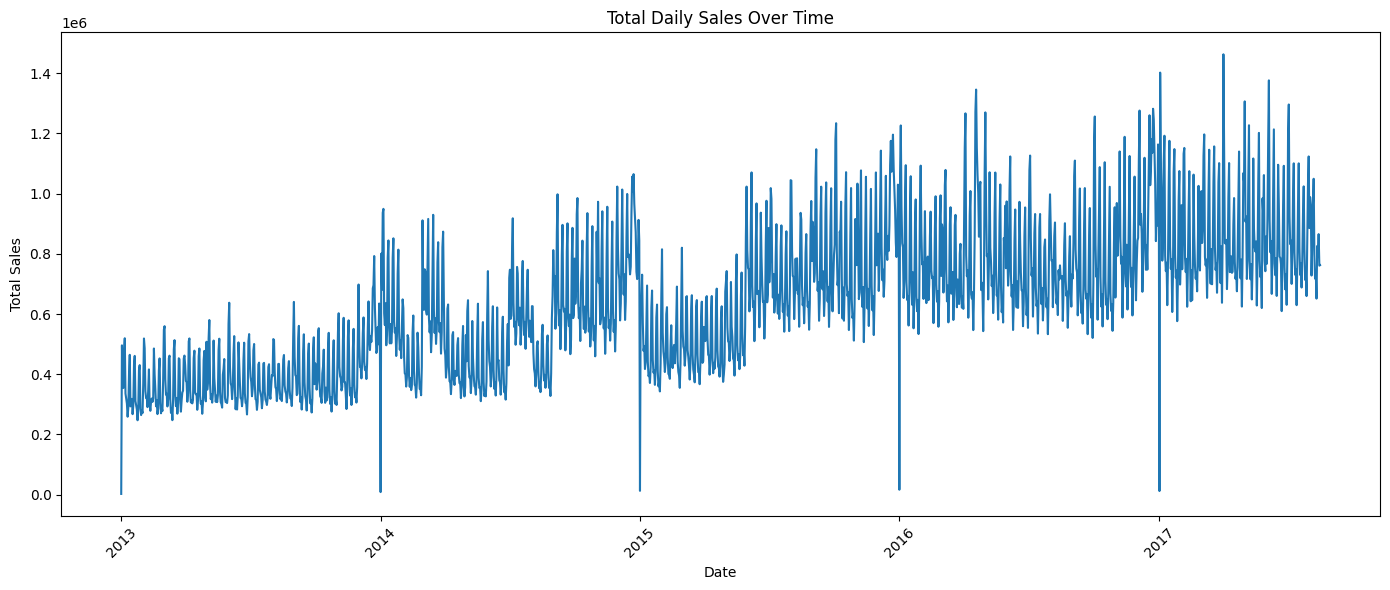

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The daily sales analysis shows a general upward trend in total sales from 2013 to 2017, accompanied by substantial day-to-day fluctuations. The series also appears to exhibit recurring seasonal patterns and several unusually low-sales days. The increasing variability over time suggests that sales are influenced by temporal factors such as seasonality, holidays, promotions, and store activity. These patterns will be investigated further during the exploratory and time-series analysis stages.

In [20]:
# Calculate total sales for each month
monthly_sales = train.groupby(
    train["date"].dt.to_period("M")
)["sales"].sum().reset_index()

# Convert the month back to a datetime format
monthly_sales["date"] = monthly_sales["date"].dt.to_timestamp()

# Display the first few results
monthly_sales.head()

,date,sales
0,2013-01-01,1.032762e+07
1,2013-02-01,9.658960e+06
2,2013-03-01,1.142850e+07
3,2013-04-01,1.099346e+07
4,2013-05-01,1.159770e+07


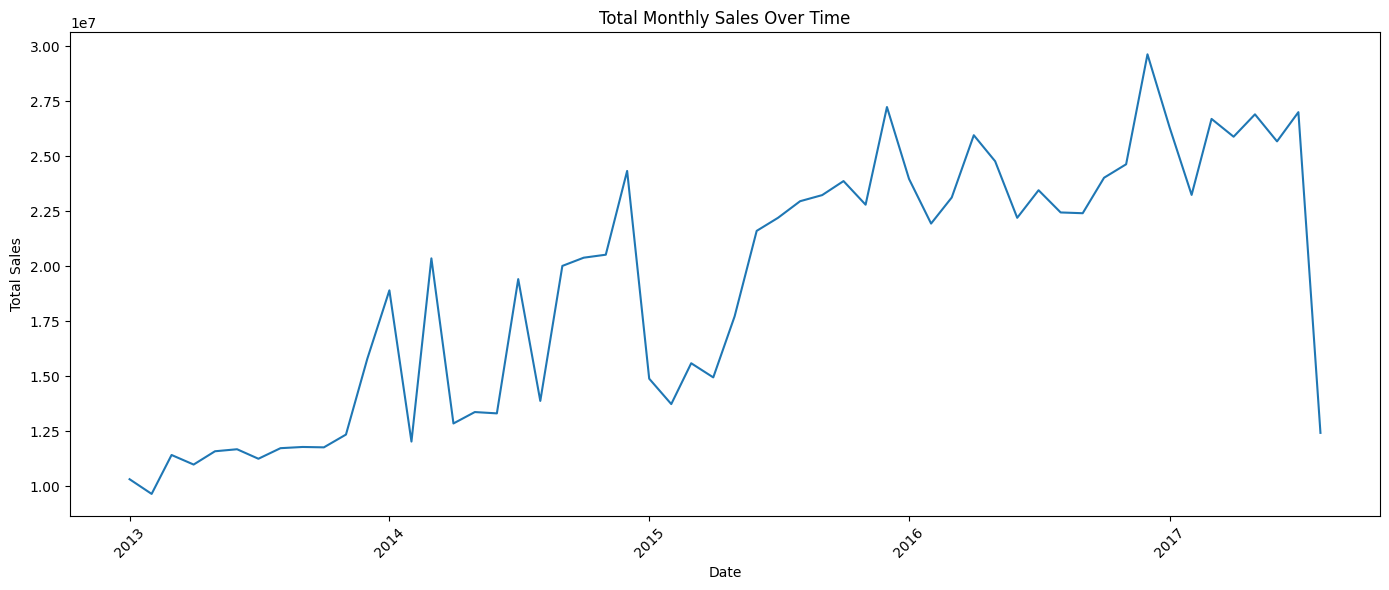

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_sales["date"], monthly_sales["sales"])

plt.title("Total Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly sales analysis reveals a strong overall upward trend in sales between 2013 and 2017. However, sales also exhibit considerable month-to-month fluctuations, suggesting the influence of additional temporal and business factors. Possible seasonal patterns are visible and will be investigated by comparing sales across months. The apparent decline at the end of the series should be interpreted cautiously because the dataset ends on August 15, 2017, resulting in an incomplete final month.

In [22]:
# Create a month column
train["month"] = train["date"].dt.month

# Calculate average sales for each month
monthly_pattern = train.groupby("month")["sales"].mean().reset_index()

# Display the results
monthly_pattern

,month,sales
0,1,341.921554
1,2,320.928869
2,3,352.009294
3,4,339.199841
4,5,341.765820
5,6,353.597842
6,7,374.219111
7,8,336.992535
8,9,362.297418
9,10,362.407132


The monthly analysis indicates variation in average sales across different months of the year. December recorded the highest average sales (453.74), while February recorded the lowest (320.93). Sales generally appear stronger toward the latter part of the year, suggesting the presence of monthly seasonal patterns. These patterns may be influenced by holidays, promotions, and changes in consumer demand and will be investigated further.

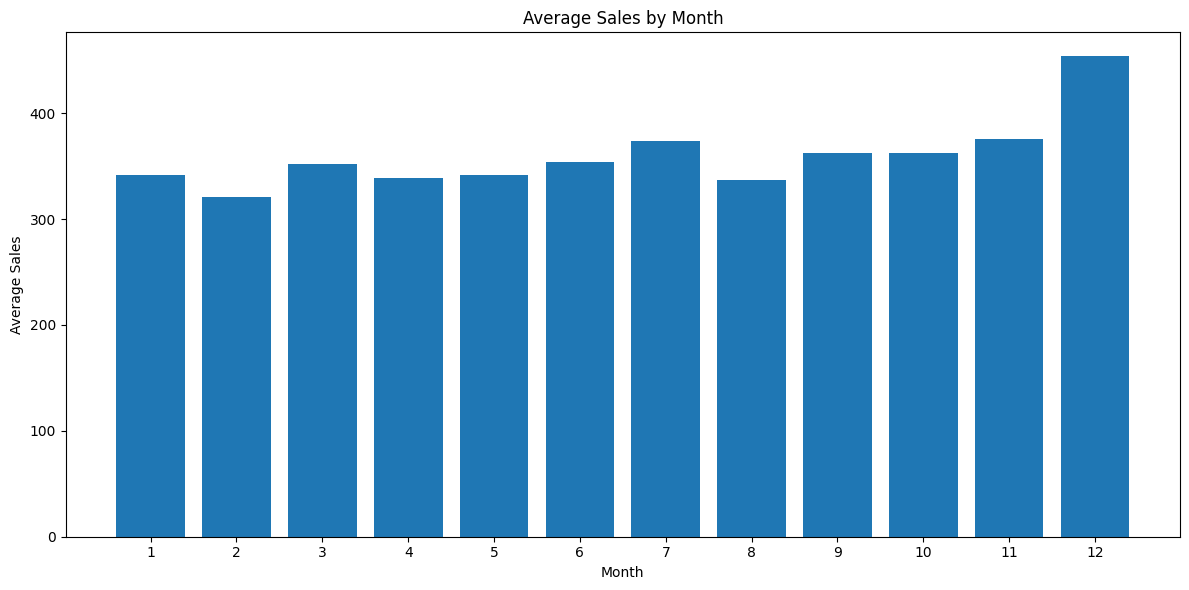

In [23]:
plt.figure(figsize=(12, 6))

plt.bar(monthly_pattern["month"], monthly_pattern["sales"])

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

The monthly sales pattern indicates that sales vary across the year, with December showing substantially higher average sales than other months. February records the lowest average sales. This suggests that seasonality may be an important factor in predicting sales.

In [24]:
# Create a day-of-week column
train["day_of_week"] = train["date"].dt.day_name()

# Calculate average sales for each day
weekly_pattern = train.groupby("day_of_week")["sales"].mean().reset_index()

# Display the results
weekly_pattern

,day_of_week,sales
0,Friday,325.238138
1,Monday,346.544732
2,Saturday,433.336472
3,Sunday,463.085366
4,Thursday,283.540517
5,Tuesday,319.823843
6,Wednesday,332.909401


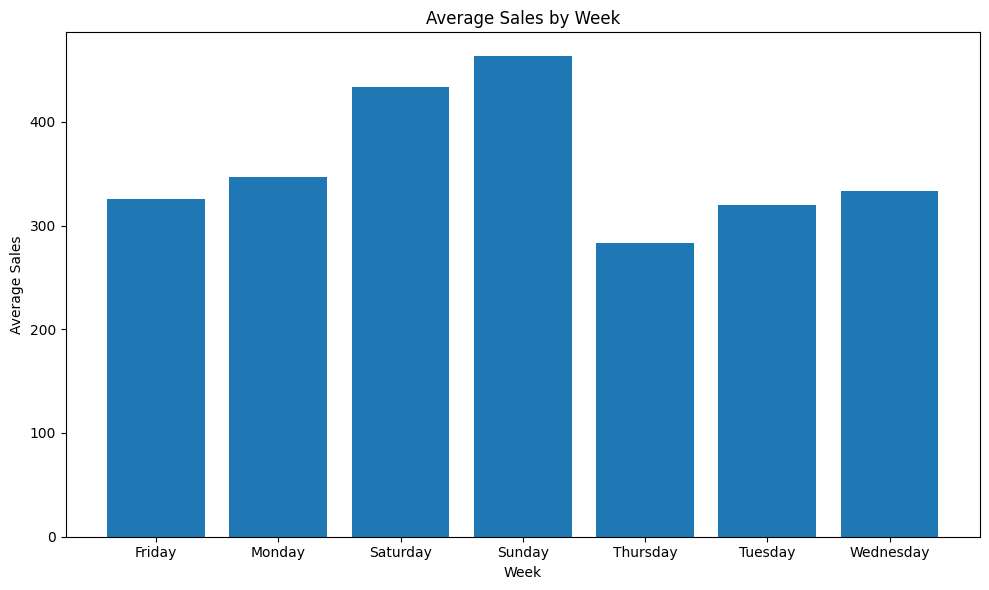

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(weekly_pattern["day_of_week"], weekly_pattern["sales"])

plt.title("Average Sales by Week")
plt.xlabel("Week")
plt.ylabel("Average Sales")

plt.xticks(range( 7))
plt.tight_layout()
plt.show()

Average sales vary substantially across the days of the week. Sunday recorded the highest average sales at 463.09, followed by Saturday at 433.34, while Thursday recorded the lowest average sales at 283.54. The higher sales observed during weekends suggest that day-of-week effects may be an important factor in explaining and forecasting retail sales.

In [26]:
# Calculate average sales for each store
store_sales = train.groupby("store_nbr")["sales"].mean().reset_index()

# Sort from highest to lowest average sales
store_sales = store_sales.sort_values(
    "sales",
    ascending=False
)

# Display the top 10 stores
store_sales.head(10)

,store_nbr,sales
43,44,1117.245254
44,45,980.673908
46,47,916.798209
2,3,908.405495
48,49,781.330450
45,46,753.905962
47,48,646.604950
50,51,592.231511
7,8,548.734739
49,50,515.601753


Store-level analysis reveals substantial variation in average sales across the 54 stores. Store 44 recorded the highest average sales at approximately 1,117.25, followed by stores 45 and 47. This variation suggests that store-specific characteristics may influence sales performance. The store metadata will therefore be examined to determine whether factors such as store type, location, and cluster are associated with differences in sales.

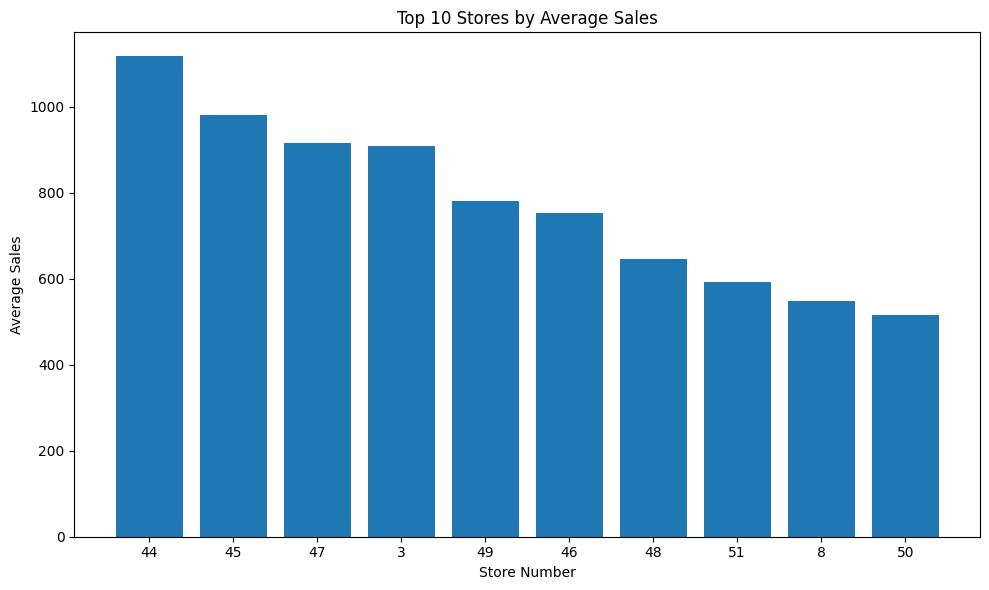

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(
    store_sales.head(10)["store_nbr"].astype(str),
    store_sales.head(10)["sales"]
)

plt.title("Top 10 Stores by Average Sales")
plt.xlabel("Store Number")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### STORE METADATA

The store metadata provides additional information that can help explain differences in sales between stores.

Store type and cluster can capture similarities between stores, while city and state provide geographical context.

These variables allow the model to distinguish between stores rather than treating all stores as having identical sales behaviour.

In [28]:
# Display the 10 stores with the highest average sales
store_sales.head(10).sort_values("sales")

,store_nbr,sales
49,50,515.601753
7,8,548.734739
50,51,592.231511
47,48,646.604950
45,46,753.905962
48,49,781.330450
2,3,908.405495
46,47,916.798209
44,45,980.673908
43,44,1117.245254


In [29]:
# Display the 10 stores with the lowest average sales
store_sales.tail(10).sort_values("sales")

,store_nbr,sales
51,52,48.516694
21,22,73.601845
31,32,107.100626
29,30,132.838006
34,35,138.139340
25,26,139.550887
41,42,160.976173
20,21,166.549808
9,10,172.999096
28,29,175.001038


In [30]:
# Display the store information
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [31]:
# Check the structure of the stores dataset
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [32]:
# Count the number of stores in each store type
stores["type"].value_counts()

type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64

In [33]:
# Merge store information with the sales data
train_store = train.merge(
    stores,
    on="store_nbr",
    how="left"
)

# Check the result
train_store.head()

,id,date,store_nbr,family,sales,onpromotion,month,day_of_week,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,Tuesday,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,1,Tuesday,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,1,Tuesday,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,Tuesday,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,1,Tuesday,Quito,Pichincha,D,13


In [34]:
# Calculate average sales for each store type
sales_by_type = train_store.groupby("type")["sales"].mean().reset_index()

# Sort from highest to lowest
sales_by_type = sales_by_type.sort_values("sales", ascending=False)

# Display the results
sales_by_type

,type,sales
0,A,705.878743
3,D,350.979407
1,B,326.739714
4,E,269.121301
2,C,197.263301


The analysis shows substantial differences in average sales across store types. Type A stores recorded the highest average sales at approximately 705.88, while Type C stores recorded the lowest at approximately 197.26. This suggests that store type may be an important factor associated with sales performance. Further analysis is required to determine whether other characteristics, such as location and store cluster, help explain these differences.

In [35]:
# Calculate average sales for each state
sales_by_state = train_store.groupby("state")["sales"].mean().reset_index()

# Sort from highest to lowest
sales_by_state = sales_by_state.sort_values("sales", ascending=False)

# Display the results
sales_by_state

,state,sales
12,Pichincha,554.110358
15,Tungurahua,362.632273
8,Loja,339.379530
4,El Oro,300.392253
5,Esmeraldas,294.963151
0,Azuay,294.924279
9,Los Rios,287.243342
6,Guayas,270.172671
1,Bolivar,234.821670
14,Santo Domingo de los Tsachilas,214.942315


Average sales varied considerably across states. Pichincha recorded the highest average sales at 554.11, while Pastaza recorded the lowest at 73.60. Tungurahua and Loja also showed relatively high average sales. These differences indicate that geographical location may be associated with sales performance. However, other factors such as store type, store characteristics, product mix, and customer demand may also contribute to these differences.

In [36]:
# Calculate average sales for each store cluster
sales_by_cluster = train_store.groupby("cluster")["sales"].mean().reset_index()

# Sort from highest to lowest
sales_by_cluster = sales_by_cluster.sort_values("sales", ascending=False)

# Display the results
sales_by_cluster

,cluster,sales
4,5,1117.245254
13,14,708.227718
7,8,647.377856
10,11,603.507018
16,17,592.231511
5,6,342.661732
0,1,326.163967
11,12,324.461406
12,13,324.364108
3,4,296.572872


Average sales differed substantially across store clusters. Cluster 5 recorded the highest average sales of 1,117.25, while Cluster 7 recorded the lowest at 139.26. This large variation suggests that store cluster characteristics may be associated with differences in sales performance. Therefore, cluster information may provide useful predictive information when developing the sales forecasting model.

In [37]:
# Calculate average sales for each product family
sales_by_family = train.groupby("family")["sales"].mean().reset_index()

# Sort from highest to lowest
sales_by_family = sales_by_family.sort_values("sales", ascending=False)

# Display the results
sales_by_family

,family,sales
12,GROCERY I,3776.972100
3,BEVERAGES,2385.793151
30,PRODUCE,1349.352123
7,CLEANING,1072.416744
8,DAIRY,709.154889
5,BREAD/BAKERY,463.336254
28,POULTRY,350.532292
24,MEATS,341.849965
25,PERSONAL CARE,270.432513
9,DELI,265.135067


The analysis shows substantial variation in average sales across product families. Grocery I recorded the highest average sales at 3,776.97, followed by Beverages at 2,385.79 and Produce at 1,349.35. In contrast, Books and Baby Care recorded very low average sales. These differences indicate that product family is an important factor associated with retail sales and should be considered during feature engineering and forecasting.

In [38]:
# Calculate the average sales for different promotion levels
promotion_sales = train.groupby("onpromotion")["sales"].mean().reset_index()

# Display the first 20 promotion levels
promotion_sales.head(20)

,onpromotion,sales
0,0,158.246681
1,1,467.556532
2,2,662.925632
3,3,871.408092
4,4,969.916135
5,5,1010.659835
6,6,1022.854287
7,7,1022.567058
8,8,1174.757003
9,9,1258.733993


The analysis indicates a generally positive association between the number of products on promotion and average sales. Records with no products on promotion had average sales of 158.25, compared with 1,619.29 for records with 19 products on promotion. Although the relationship is not perfectly linear, the results suggest that promotional activity may be an important factor associated with sales performance and should be considered in the forecasting model.

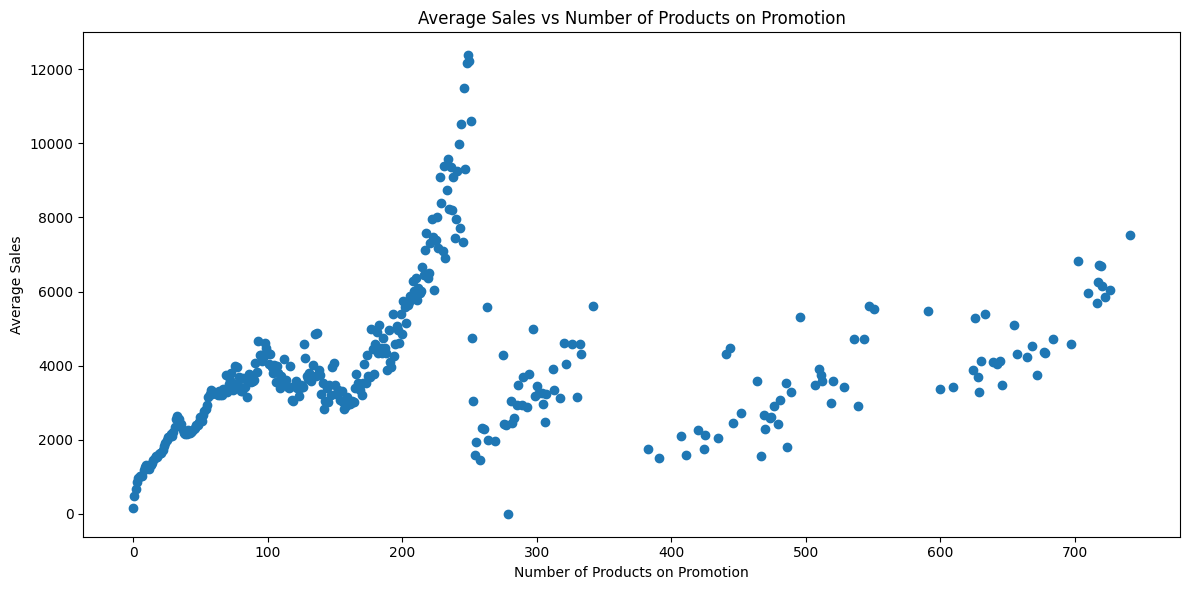

In [39]:
plt.figure(figsize=(12, 6))

plt.scatter(
    promotion_sales["onpromotion"],
    promotion_sales["sales"]
)

plt.title("Average Sales vs Number of Products on Promotion")
plt.xlabel("Number of Products on Promotion")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

The scatter plot indicates a generally positive association between promotional activity and average sales. As the number of products on promotion increases, average sales tend to increase, although the relationship is not perfectly linear. This suggests that promotional activity may be an important factor associated with sales performance. However, the relationship should not be interpreted as causal because other factors, including product family, store characteristics, seasonality, and holidays, may also influence sales.

In [40]:
# Calculate the correlation between promotions and sales

correlation = train["onpromotion"].corr(train["sales"])

print("Correlation between promotions and sales:", correlation)

Correlation between promotions and sales: 0.42792320481213236


The correlation coefficient of 0.428 indicates a moderate positive linear relationship between promotional activity and sales. This suggests that higher promotional activity is generally associated with higher sales. However, correlation does not imply causation, and other factors may also contribute to sales performance.

### Holidays and Events
Within the period covered by the training data, 286 holiday and event records were identified.

Holidays were the most common event type, followed by Events and Additional events.

These events may influence consumer purchasing behaviour and therefore represent potentially useful information for sales forecasting.

In [41]:
# Look at the holiday dataset
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [42]:
# Count the different types of events
holidays["type"].value_counts()

type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

In [43]:
# Count events by geographical scope
holidays["locale"].value_counts()

locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

In [44]:
# Convert holiday dates to datetime format
holidays["date"] = pd.to_datetime(holidays["date"])

# Check the data type
holidays["date"].dtype

dtype('<M8[ns]')

In [45]:
# Filter holidays to the sales period
holidays_period = holidays[
    (holidays["date"] >= train["date"].min()) &
    (holidays["date"] <= train["date"].max())
]

print("Number of holiday/event records in sales period:", len(holidays_period))

Number of holiday/event records in sales period: 286


In [46]:
holidays_period["type"].value_counts()

type
Holiday       175
Event          56
Additional     38
Transfer        9
Work Day        5
Bridge          3
Name: count, dtype: int64

Within the sales period, 286 holiday and event records were identified. Holidays were the most common event type, with 175 records, followed by Events with 56 records and Additional events with 38 records. These events may influence consumer purchasing patterns and therefore represent potentially useful variables for sales forecasting.

In [47]:
holidays_period["locale"].value_counts()

locale
National    151
Local       117
Regional     18
Name: count, dtype: int64

Of the 286 holiday and event records within the sales period, 151 were national, 117 were local, and 18 were regional. National events have the potential to affect sales across all stores, whereas local and regional events are geographically specific. Therefore, the location scope of events should be considered when incorporating holiday information into the forecasting model.

In [48]:
holidays_period[["date", "type", "locale", "locale_name", "description"]].head(20)

,date,type,locale,locale_name,description
41,2013-01-01,Holiday,National,Ecuador,Primer dia del ano
42,2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad
43,2013-01-12,Work Day,National,Ecuador,Recupero puente primer dia del ano
44,2013-02-11,Holiday,National,Ecuador,Carnaval
45,2013-02-12,Holiday,National,Ecuador,Carnaval
46,2013-03-02,Holiday,Local,Manta,Fundacion de Manta
47,2013-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi
48,2013-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca
49,2013-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad
50,2013-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba


OIL PRICES

In [49]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [50]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


In [51]:
oil.describe()

,dcoilwtico
count,1175.000000
mean,67.714366
std,25.630476
min,26.190000
25%,46.405000
50%,53.190000
75%,95.660000
max,110.620000


In [52]:
oil[oil["dcoilwtico"].isna()]

,date,dcoilwtico
0,2013-01-01,NaN
14,2013-01-21,NaN
34,2013-02-18,NaN
63,2013-03-29,NaN
104,2013-05-27,NaN
132,2013-07-04,NaN
174,2013-09-02,NaN
237,2013-11-28,NaN
256,2013-12-25,NaN
261,2014-01-01,NaN


In [53]:
# Convert date to datetime
oil["date"] = pd.to_datetime(oil["date"])

# Sort by date
oil = oil.sort_values("date")

# Fill missing oil prices with the previous available value
oil["dcoilwtico"] = oil["dcoilwtico"].ffill()

# Check for remaining missing values
oil.isnull().sum()

date          0
dcoilwtico    1
dtype: int64

In [54]:
# Fill the remaining missing oil price using the next available value
oil["dcoilwtico"] = oil["dcoilwtico"].bfill()

# Check again
oil.isnull().sum()

date          0
dcoilwtico    0
dtype: int64

TRANSACTIONS

In [55]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [56]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


In [57]:
# Convert transaction dates to datetime
transactions["date"] = pd.to_datetime(transactions["date"])

# Check the data type
transactions["date"].dtype

dtype('<M8[ns]')

In [58]:
print("Transaction start date:", transactions["date"].min())
print("Transaction end date:", transactions["date"].max())

Transaction start date: 2013-01-01 00:00:00
Transaction end date: 2017-08-15 00:00:00


In [59]:
# Check for duplicate rows
transactions.duplicated().sum()

np.int64(0)

In [60]:
transactions["transactions"].describe()

count    83488.000000
mean      1694.602158
std        963.286644
min          5.000000
25%       1046.000000
50%       1393.000000
75%       2079.000000
max       8359.000000
Name: transactions, dtype: float64

The transaction data shows considerable variation in daily customer activity across stores. The average number of transactions was 1,694.60, with a median of 1,393 and a maximum of 8,359 transactions. The difference between the mean and median suggests a right-skewed distribution. Transaction activity may therefore provide useful information for explaining and forecasting sales.

In [61]:
# Calculate total transactions per day
daily_transactions = transactions.groupby("date")["transactions"].sum().reset_index()

# Display the first 5 rows
daily_transactions.head()

,date,transactions
0,2013-01-01,770
1,2013-01-02,93215
2,2013-01-03,78504
3,2013-01-04,78494
4,2013-01-05,93573


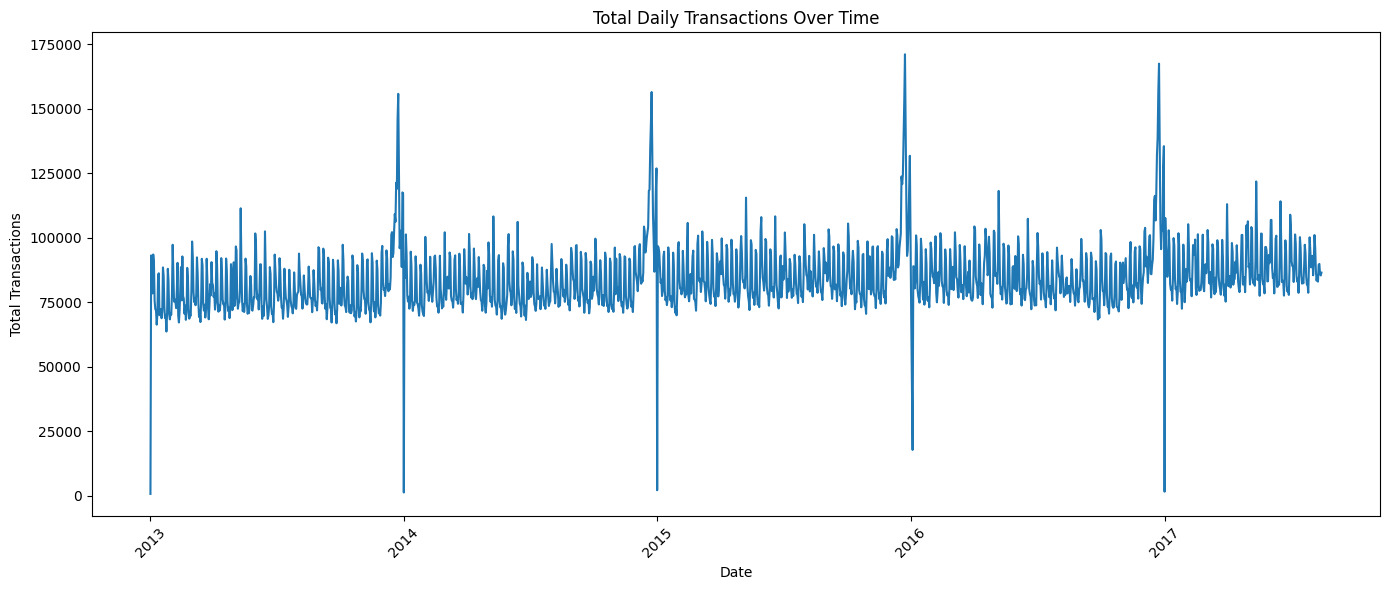

In [62]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_transactions["date"],
    daily_transactions["transactions"]
)

plt.title("Total Daily Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Total Transactions")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The daily transaction analysis shows considerable variation in customer activity throughout the study period. Overall, transaction volumes exhibit a gradual upward trend, although strong day-to-day fluctuations and occasional spikes are present. The recurring patterns suggest that calendar effects, holidays, and other temporal factors may influence transaction activity. Since transaction volume reflects customer activity at the store level, it may provide useful information for explaining and forecasting sales.

In [63]:
# Merge daily sales and daily transactions
sales_transactions = daily_sales.merge(
    daily_transactions,
    on="date",
    how="inner"
)

sales_transactions.head()

,date,sales,transactions
0,2013-01-01,2511.618999,770
1,2013-01-02,496092.417944,93215
2,2013-01-03,361461.231124,78504
3,2013-01-04,354459.677093,78494
4,2013-01-05,477350.121229,93573


In [64]:
# Calculate the correlation between transactions and sales
correlation = sales_transactions["sales"].corr(
    sales_transactions["transactions"]
)

print("Correlation between transactions and sales:", correlation)

Correlation between transactions and sales: 0.6765087007296068


The correlation coefficient between daily transactions and sales was 0.677, indicating a moderately strong positive linear relationship. This suggests that days with higher transaction volumes generally tend to have higher sales. However, the correlation is not perfect, indicating that other factors also contribute to variations in sales.

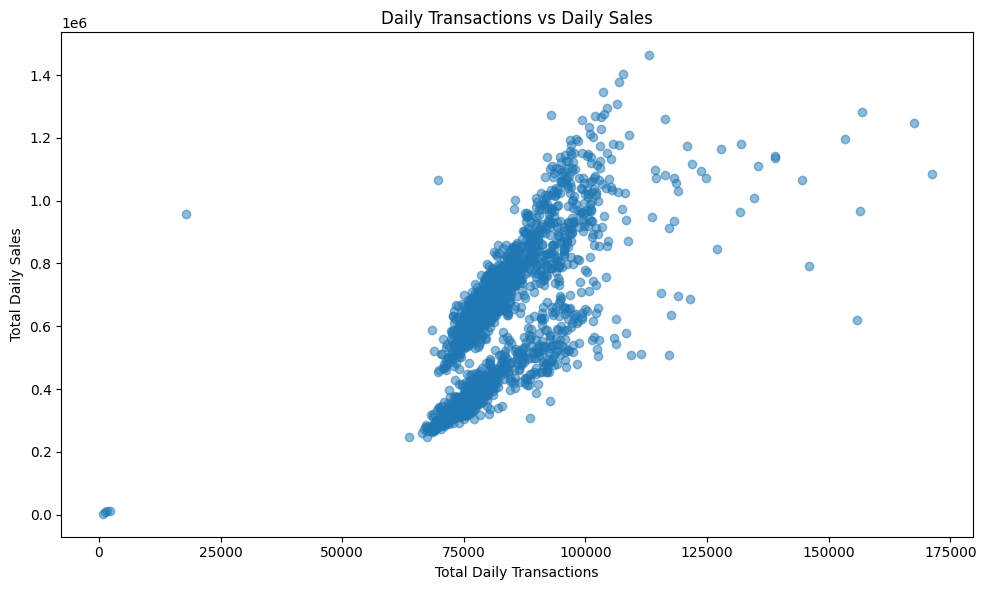

In [65]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sales_transactions["transactions"],
    sales_transactions["sales"],
    alpha=0.5
)

plt.title("Daily Transactions vs Daily Sales")
plt.xlabel("Total Daily Transactions")
plt.ylabel("Total Daily Sales")

plt.tight_layout()
plt.show()

The scatter plot shows a clear positive association between daily transactions and daily sales. Higher transaction volumes generally correspond to higher sales, although considerable variation remains at similar transaction levels. This supports the correlation result of 0.677 and suggests that transaction activity could be a useful predictor in the forecasting model.

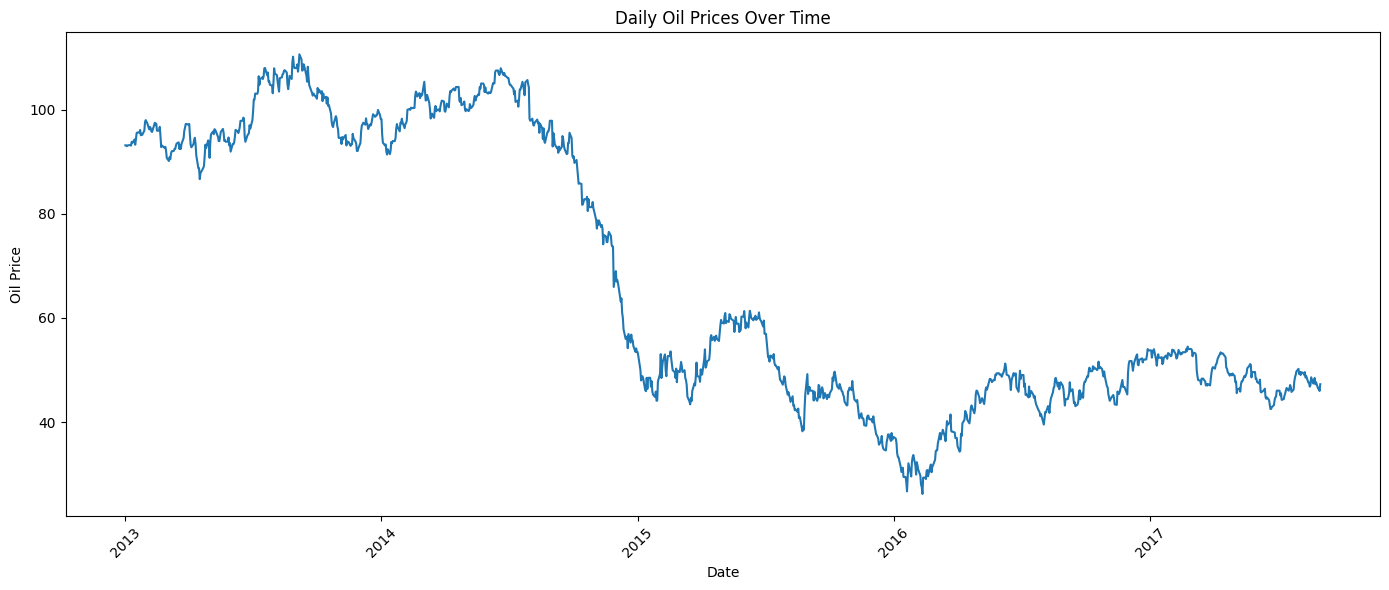

In [66]:
# Plot oil prices over time
plt.figure(figsize=(14, 6))

plt.plot(
    oil["date"],
    oil["dcoilwtico"]
)

plt.title("Daily Oil Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Oil Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The oil price analysis shows substantial fluctuations throughout the study period. Oil prices remained relatively high during 2013 and 2014 before experiencing a sharp decline from late 2014 into 2016. Prices subsequently recovered and fluctuated at lower levels through 2017. These changes indicate that oil prices may provide useful economic information when analyzing store sales, particularly because they vary over time alongside other business and economic conditions.

In [67]:
# Merge daily sales with oil prices
sales_oil = daily_sales.merge(
    oil,
    on="date",
    how="left"
)

sales_oil.head()

,date,sales,dcoilwtico
0,2013-01-01,2511.618999,93.14
1,2013-01-02,496092.417944,93.14
2,2013-01-03,361461.231124,92.97
3,2013-01-04,354459.677093,93.12
4,2013-01-05,477350.121229,NaN


In [68]:
# Sort by date
sales_oil = sales_oil.sort_values("date")

# Carry the most recent oil price forward
sales_oil["dcoilwtico"] = sales_oil["dcoilwtico"].ffill()

# Check for remaining missing values
sales_oil.isnull().sum()

date          0
sales         0
dcoilwtico    0
dtype: int64

In [69]:
# Calculate the correlation between oil prices and sales
oil_correlation = sales_oil["dcoilwtico"].corr(
    sales_oil["sales"]
)

print("Correlation between oil prices and sales:", oil_correlation)

Correlation between oil prices and sales: -0.6268894636886427


The correlation between oil prices and daily sales was -0.627, indicating a moderately strong negative linear association. This suggests that periods of higher oil prices were generally associated with lower sales, while periods of lower oil prices were associated with higher sales. However, this relationship should not be interpreted as causal, as both variables exhibit substantial changes over time and other factors may influence sales.

In [70]:
# Calculate total sales by product family
family_total_sales = train.groupby("family")["sales"].sum().reset_index()

# Sort from highest to lowest
family_total_sales = family_total_sales.sort_values(
    "sales",
    ascending=False
)

family_total_sales.head(10)

,family,sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07
5,BREAD/BAKERY,4.213395e+07
28,POULTRY,3.187600e+07
24,MEATS,3.108647e+07
25,PERSONAL CARE,2.459205e+07
9,DELI,2.411032e+07


FEATURE ENGINEERING


Feature engineeringfore used to transform the raw data into variables that represent important characteristics of the sales process.

### Calendar Features
We extracted year, month, day, and day-of-week information from the date.
We created an additional weekend indicator to distinguish Saturdays and Sundays from weekdays. 
These features allow the model to learn recurring temporal patterns in retail demand.

In [71]:
# Create calendar features from the date column
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["day_of_week_num"] = train["date"].dt.dayofweek

# 0 = Monday, 6 = Sunday
train["is_weekend"] = train["day_of_week_num"].isin([5, 6]).astype(int)

# Display the new features
train[[
    "date",
    "year",
    "month",
    "day",
    "day_of_week_num",
    "is_weekend"
]].head()

,date,year,month,day,day_of_week_num,is_weekend
0,2013-01-01,2013,1,1,1,0
1,2013-01-01,2013,1,1,1,0
2,2013-01-01,2013,1,1,1,0
3,2013-01-01,2013,1,1,1,0
4,2013-01-01,2013,1,1,1,0


### Promotion Feature 
A binary `is_onpromotion` variable was created to indicate whether at least one product in the observation was on promotion.
The original `onpromotion` variable is retained because it provides the actual number of products being promoted, while the binary variable captures the simpler distinction between promotion and no promotion.

In [72]:
# Create a binary promotion feature
train["is_onpromotion"] = (train["onpromotion"] > 0).astype(int)

# Display the new feature
train[[
    "date",
    "store_nbr",
    "family",
    "onpromotion",
    "is_onpromotion"
]].head(10)

,date,store_nbr,family,onpromotion,is_onpromotion
0,2013-01-01,1,AUTOMOTIVE,0,0
1,2013-01-01,1,BABY CARE,0,0
2,2013-01-01,1,BEAUTY,0,0
3,2013-01-01,1,BEVERAGES,0,0
4,2013-01-01,1,BOOKS,0,0
5,2013-01-01,1,BREAD/BAKERY,0,0
6,2013-01-01,1,CELEBRATION,0,0
7,2013-01-01,1,CLEANING,0,0
8,2013-01-01,1,DAIRY,0,0
9,2013-01-01,1,DELI,0,0


### Holiday Features 

Holiday indicators were created to identify whether a sales observation occurred on a holiday or event dat.

Additional indicators distinguish national, regional, and local evets.

These variables allow the model to capture possible changes in consumer behaviour associated with special dates.

In [73]:
# Create a copy of the holidays data
holiday_dates = holidays[["date"]].drop_duplicates()

# Create a holiday indicator
train["is_holiday"] = train["date"].isin(holiday_dates["date"]).astype(int)

# Display the result
train[[
    "date",
    "is_holiday"
]].head(20)

,date,is_holiday
0,2013-01-01,1
1,2013-01-01,1
2,2013-01-01,1
3,2013-01-01,1
4,2013-01-01,1
5,2013-01-01,1
6,2013-01-01,1
7,2013-01-01,1
8,2013-01-01,1
9,2013-01-01,1


In [74]:
# Add store information to the training data
train = train.merge(
    stores,
    on="store_nbr",
    how="left"
)

# Check the new columns
train[[
    "store_nbr",
    "city",
    "state",
    "type",
    "cluster"
]].head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,1,Quito,Pichincha,D,13
2,1,Quito,Pichincha,D,13
3,1,Quito,Pichincha,D,13
4,1,Quito,Pichincha,D,13


Store information was merged with the sales data using `store_nbr` as the common identifier.
This adds information such as store type, city, state, and cluster to each sales observation.
The merge was successful because no missing store information was introduced.

In [75]:
# Make sure transaction dates are in datetime format
transactions["date"] = pd.to_datetime(transactions["date"])

# Merge transactions with the training data
train = train.merge(
    transactions,
    on=["date", "store_nbr"],
    how="left"
)

# Check the result
train[[
    "date",
    "store_nbr",
    "family",
    "sales",
    "transactions"
]].head(10)

,date,store_nbr,family,sales,transactions
0,2013-01-01,1,AUTOMOTIVE,0.0,NaN
1,2013-01-01,1,BABY CARE,0.0,NaN
2,2013-01-01,1,BEAUTY,0.0,NaN
3,2013-01-01,1,BEVERAGES,0.0,NaN
4,2013-01-01,1,BOOKS,0.0,NaN
5,2013-01-01,1,BREAD/BAKERY,0.0,NaN
6,2013-01-01,1,CELEBRATION,0.0,NaN
7,2013-01-01,1,CLEANING,0.0,NaN
8,2013-01-01,1,DAIRY,0.0,NaN
9,2013-01-01,1,DELI,0.0,NaN


In [76]:
# Check missing transaction values after the merge
train["transactions"].isnull().sum()

np.int64(245784)

In [77]:
# Check the dates where transaction information is missing
missing_transactions = train[train["transactions"].isnull()]
missing_transactions["date"].describe()

count                           245784
mean     2014-07-03 07:42:05.026852608
min                2013-01-01 00:00:00
25%                2013-08-26 00:00:00
50%                2014-05-09 12:00:00
75%                2015-02-15 06:00:00
max                2017-04-19 00:00:00
Name: date, dtype: object

In [78]:
# Check how many unique dates have missing transaction information
missing_transactions["date"].nunique()

1566

In [79]:
# Check missing transactions by store
missing_by_store = (
    train[train["transactions"].isnull()]
    .groupby("store_nbr")
    .size()
    .sort_values(ascending=False)
)

missing_by_store

store_nbr
52    51678
22    33429
42    31812
21    30888
29    26730
20    25575
53    17061
36     4389
18     3894
24     3531
25     2277
12     2244
14     1518
30      957
43      396
17      330
10      297
7       297
3       264
1       264
4       264
11      264
6       264
35      264
54      264
19      264
9       264
8       264
15      264
13      264
16      231
5       231
2       231
45      231
32      231
27      231
28      231
23      231
50      231
46      231
44      231
47      231
48      231
49      231
41      231
40      231
51      231
37      198
38      198
34      198
31      198
26      198
33      198
39      198
dtype: int64

In [80]:
# Count unique store-date combinations with missing transactions
missing_store_dates = (
    train[train["transactions"].isnull()]
    [["date", "store_nbr"]]
    .drop_duplicates()
)

print("Missing store-date combinations:", len(missing_store_dates))
print("Total possible store-date combinations:", 
      train[["date", "store_nbr"]].drop_duplicates().shape[0])

Missing store-date combinations: 7448
Total possible store-date combinations: 90936


In [81]:
# Calculate the percentage of missing transaction values
missing_percentage = train["transactions"].isnull().mean() * 100
print(f"Missing transaction values: {missing_percentage:.2f}%")

Missing transaction values: 8.19%


In [82]:
# Make sure the oil date column is in datetime format
oil["date"] = pd.to_datetime(oil["date"])

# Merge oil prices into the training data
train = train.merge(
    oil[["date", "dcoilwtico"]],
    on="date",
    how="left"
)

train[["date", "dcoilwtico"]].head(10)

,date,dcoilwtico
0,2013-01-01,93.14
1,2013-01-01,93.14
2,2013-01-01,93.14
3,2013-01-01,93.14
4,2013-01-01,93.14
5,2013-01-01,93.14
6,2013-01-01,93.14
7,2013-01-01,93.14
8,2013-01-01,93.14
9,2013-01-01,93.14


In [83]:
# Check for missing oil prices after merging
missing_oil = train["dcoilwtico"].isnull().sum()
missing_oil_percentage = train["dcoilwtico"].isnull().mean() * 100

print("Missing oil price values:", missing_oil)
print(f"Missing oil price percentage: {missing_oil_percentage:.2f}%")

Missing oil price values: 857142
Missing oil price percentage: 28.56%


In [84]:
# Find dates where the oil price is missing
missing_oil_dates = (
    train[train["dcoilwtico"].isnull()]
    [["date"]]
    .drop_duplicates()
    .sort_values("date")
)

print("Number of dates with missing oil prices:", len(missing_oil_dates))

missing_oil_dates.head(20)

Number of dates with missing oil prices: 481


,date
7128,2013-01-05
8910,2013-01-06
19602,2013-01-12
21384,2013-01-13
32076,2013-01-19
33858,2013-01-20
44550,2013-01-26
46332,2013-01-27
57024,2013-02-02
58806,2013-02-03


In [85]:
# Fill missing oil prices using the most recent available price
train["dcoilwtico"] = train["dcoilwtico"].ffill()

# Check the result
missing_oil_after = train["dcoilwtico"].isnull().sum()
print("Missing oil prices after filling:", missing_oil_after)

Missing oil prices after filling: 0



Daily oil prices were merged with the sales data using the dat.

The oil dataset contains missing prices on some dates, largely because oil prices are not reported every calendar day. Forward filling was used to carry the most recent available oil price forwrd.

After this treatment, no missing oil prices remained in the training data.

In [86]:
# Create more detailed holiday features
train["is_national_holiday"] = train["date"].isin(
    holidays.loc[holidays["locale"] == "National", "date"]
).astype(int)

train["is_regional_holiday"] = train["date"].isin(
    holidays.loc[holidays["locale"] == "Regional", "date"]
).astype(int)

train["is_local_holiday"] = train["date"].isin(
    holidays.loc[holidays["locale"] == "Local", "date"]
).astype(int)

# Check the new features
train[[
    "date",
    "is_holiday",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday"
]].head(20)

,date,is_holiday,is_national_holiday,is_regional_holiday,is_local_holiday
0,2013-01-01,1,1,0,0
1,2013-01-01,1,1,0,0
2,2013-01-01,1,1,0,0
3,2013-01-01,1,1,0,0
4,2013-01-01,1,1,0,0
5,2013-01-01,1,1,0,0
6,2013-01-01,1,1,0,0
7,2013-01-01,1,1,0,0
8,2013-01-01,1,1,0,0
9,2013-01-01,1,1,0,0


In [87]:
# Check missing values in the main features
important_columns = [
    "date",
    "store_nbr",
    "family",
    "sales",
    "onpromotion",
    "transactions",
    "dcoilwtico",
    "is_holiday",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday"
]

missing_summary = train[important_columns].isnull().sum()

print(missing_summary)

date                        0
store_nbr                   0
family                      0
sales                       0
onpromotion                 0
transactions           245784
dcoilwtico                  0
is_holiday                  0
is_national_holiday         0
is_regional_holiday         0
is_local_holiday            0
dtype: int64


In [88]:
# Check the final shape of the training data
print("Final training data shape:", train.shape)

# Check for duplicate rows
duplicate_rows = train.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Final training data shape: (3000888, 23)
Duplicate rows: 0


In [89]:
# Check the date range of the training data
print("Earliest date:", train["date"].min())
print("Latest date:", train["date"].max())

# Show the last few dates
train[["date", "sales"]].tail()

Earliest date: 2013-01-01 00:00:00
Latest date: 2017-08-15 00:00:00


,date,sales
3000883,2017-08-15,438.133
3000884,2017-08-15,154.553
3000885,2017-08-15,2419.729
3000886,2017-08-15,121.000
3000887,2017-08-15,16.000


In [90]:
# Define the validation period
validation_start = pd.Timestamp("2017-06-01")

train_data = train[train["date"] < validation_start].copy()
validation_data = train[train["date"] >= validation_start].copy()

print("Training data shape:", train_data.shape)
print("Validation data shape:", validation_data.shape)

print("\nTraining period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nValidation period:")
print(validation_data["date"].min(), "to", validation_data["date"].max())

Training data shape: (2865456, 23)
Validation data shape: (135432, 23)

Training period:
2013-01-01 00:00:00 to 2017-05-31 00:00:00

Validation period:
2017-06-01 00:00:00 to 2017-08-15 00:00:00


In [91]:
# Select the features we will initially use for forecasting
model_features = [
    "store_nbr",
    "family",
    "onpromotion",
    "dcoilwtico",
    "is_holiday",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "year",
    "month",
    "day",
    "day_of_week_num",
    "is_weekend",
    "type",
    "cluster"
]

print("Number of features:", len(model_features))
print("\nFeatures:")
print(model_features)

Number of features: 15

Features:
['store_nbr', 'family', 'onpromotion', 'dcoilwtico', 'is_holiday', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'year', 'month', 'day', 'day_of_week_num', 'is_weekend', 'type', 'cluster']


In [92]:
# Convert categorical variables into numerical dummy variables
train_model = pd.get_dummies(
    train,
    columns=["family", "type"],
    drop_first=True
)

print("New training data shape:", train_model.shape)

train_model.head()

New training data shape: (3000888, 57)


,id,date,store_nbr,sales,onpromotion,month,day_of_week,year,day,day_of_week_num,...,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD,type_B,type_C,type_D,type_E
0,0,2013-01-01,1,0.0,0,1,Tuesday,2013,1,1,...,False,False,False,False,False,False,False,False,True,False
1,1,2013-01-01,1,0.0,0,1,Tuesday,2013,1,1,...,False,False,False,False,False,False,False,False,True,False
2,2,2013-01-01,1,0.0,0,1,Tuesday,2013,1,1,...,False,False,False,False,False,False,False,False,True,False
3,3,2013-01-01,1,0.0,0,1,Tuesday,2013,1,1,...,False,False,False,False,False,False,False,False,True,False
4,4,2013-01-01,1,0.0,0,1,Tuesday,2013,1,1,...,False,False,False,False,False,False,False,False,True,False


In [93]:
# Separate predictors (X) and target variable (y)
X = train_model.drop(
    columns=["sales", "id", "date", "day_of_week", "city", "state", "transactions"]
)

y = train_model["sales"]

# Make sure all predictor columns are numeric
X = X.astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nData types:")
print(X.dtypes.value_counts())

X shape: (3000888, 50)
y shape: (3000888,)

Data types:
float64    50
Name: count, dtype: int64


In [94]:
# Use the same time-based split for the machine-learning data
train_indices = train["date"] < validation_start
validation_indices = train["date"] >= validation_start

X_train = X.loc[train_indices]
X_validation = X.loc[validation_indices]

y_train = y.loc[train_indices]
y_validation = y.loc[validation_indices]

print("X_train shape:", X_train.shape)
print("X_validation shape:", X_validation.shape)

print("y_train shape:", y_train.shape)
print("y_validation shape:", y_validation.shape)

X_train shape: (2865456, 50)
X_validation shape: (135432, 50)
y_train shape: (2865456,)
y_validation shape: (135432,)


In [95]:
# Create a simple baseline using historical average sales
# for each store and product family
baseline_means = (
    train_data
    .groupby(["store_nbr", "family"])["sales"]
    .mean()
    .reset_index(name="baseline_sales")
)

# Add the baseline predictions to the validation data
validation_baseline = validation_data[
    ["store_nbr", "family", "sales"]
].merge(
    baseline_means,
    on=["store_nbr", "family"],
    how="left"
)

print(validation_baseline.head())
print("\nMissing baseline predictions:",
      validation_baseline["baseline_sales"].isnull().sum())

   store_nbr      family   sales  baseline_sales
0          1  AUTOMOTIVE     6.0        3.183458
1          1   BABY CARE     0.0        0.000000
2          1      BEAUTY     1.0        2.358209
3          1   BEVERAGES  2250.0     1559.901119
4          1       BOOKS     3.0        0.117537

Missing baseline predictions: 0


In [96]:
from sklearn.metrics import mean_squared_log_error

# Calculate RMSLE for the baseline
baseline_rmsle = np.sqrt(
    mean_squared_log_error(
        validation_baseline["sales"],
        validation_baseline["baseline_sales"]
    )
)

print(f"Baseline RMSLE: {baseline_rmsle:.4f}")

Baseline RMSLE: 0.7138


In [97]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [98]:
# Make predictions on the validation data
y_pred = model.predict(X_validation)

# Sales predictions cannot be negative
y_pred = np.maximum(y_pred, 0)

print("Predictions completed.")
print("First 10 predictions:")
print(y_pred[:10])

Predictions completed.
First 10 predictions:
[  10.00558562   10.00558562   10.00558562 2675.43341228   10.00558562
  356.0180017    10.00558562  969.60283685  773.30951689  149.01196044]


In [99]:
from sklearn.metrics import mean_squared_log_error
model_rmsle = np.sqrt(
    mean_squared_log_error(
        y_validation,
        y_pred
    )
)

print(f"Model RMSLE: {model_rmsle:.4f}")
print(f"Baseline RMSLE: {baseline_rmsle:.4f}")

Model RMSLE: 1.4568
Baseline RMSLE: 0.7138


The HistGradientBoosting model achieved an RMSLE of 1.4568, which was substantially higher than the baseline RMSLE of 0.7138. Since lower RMSLE indicates better forecasting performance, the baseline provided more accurate predictions. This suggests that the current feature set does not adequately capture the temporal dependence of retail sales. In particular, historical sales patterns such as recent sales and weekly lagged sales may be important predictors. Therefore, lag and rolling-window features will be introduced in the next stage to improve the forecasting model.

In [100]:
# Sort the data before creating lag features
train = train.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

print("Data sorted successfully.")
print(train[[
    "date",
    "store_nbr",
    "family",
    "sales"
]].head(10))

Data sorted successfully.
        date  store_nbr      family  sales
0 2013-01-01          1  AUTOMOTIVE    0.0
1 2013-01-02          1  AUTOMOTIVE    2.0
2 2013-01-03          1  AUTOMOTIVE    3.0
3 2013-01-04          1  AUTOMOTIVE    3.0
4 2013-01-05          1  AUTOMOTIVE    5.0
5 2013-01-06          1  AUTOMOTIVE    2.0
6 2013-01-07          1  AUTOMOTIVE    0.0
7 2013-01-08          1  AUTOMOTIVE    2.0
8 2013-01-09          1  AUTOMOTIVE    2.0
9 2013-01-10          1  AUTOMOTIVE    2.0


In [101]:
# Create historical sales (lag) features
train["lag_1"] = (
    train.groupby(["store_nbr", "family"])["sales"]
    .shift(1)
)

train["lag_7"] = (
    train.groupby(["store_nbr", "family"])["sales"]
    .shift(7)
)

train["lag_14"] = (
    train.groupby(["store_nbr", "family"])["sales"]
    .shift(14)
)

print("Lag features created.")

train[[
    "date",
    "store_nbr",
    "family",
    "sales",
    "lag_1",
    "lag_7",
    "lag_14"
]].head(20)

Lag features created.


,date,store_nbr,family,sales,lag_1,lag_7,lag_14
0,2013-01-01,1,AUTOMOTIVE,0.0,NaN,NaN,NaN
1,2013-01-02,1,AUTOMOTIVE,2.0,0.0,NaN,NaN
2,2013-01-03,1,AUTOMOTIVE,3.0,2.0,NaN,NaN
3,2013-01-04,1,AUTOMOTIVE,3.0,3.0,NaN,NaN
4,2013-01-05,1,AUTOMOTIVE,5.0,3.0,NaN,NaN
5,2013-01-06,1,AUTOMOTIVE,2.0,5.0,NaN,NaN
6,2013-01-07,1,AUTOMOTIVE,0.0,2.0,NaN,NaN
7,2013-01-08,1,AUTOMOTIVE,2.0,0.0,0.0,NaN
8,2013-01-09,1,AUTOMOTIVE,2.0,2.0,2.0,NaN
9,2013-01-10,1,AUTOMOTIVE,2.0,2.0,3.0,NaN


Lag features were successfully created for each store–product family combination. The lag_1, lag_7, and lag_14 variables represent sales from 1, 7, and 14 days earlier, respectively. These features allow the forecasting model to incorporate recent and weekly historical sales patterns, which were not captured by the initial model. The missing values at the beginning of each store–family series are expected because sufficient historical observations are not available.

In [102]:
# Check missing values in the lag features

print("Missing lag_1:", train["lag_1"].isnull().sum())
print("Missing lag_7:", train["lag_7"].isnull().sum())
print("Missing lag_14:", train["lag_14"].isnull().sum())

Missing lag_1: 1782
Missing lag_7: 12474
Missing lag_14: 24948


In [103]:
# Remove rows where lag features are not available
train_lag = train.dropna(
    subset=["lag_1", "lag_7", "lag_14"]
).copy()

print("Original training data shape:", train.shape)
print("Training data after removing missing lags:", train_lag.shape)

print("\nMissing lag values after removal:")
print(train_lag[["lag_1", "lag_7", "lag_14"]].isnull().sum())

Original training data shape: (3000888, 26)
Training data after removing missing lags: (2975940, 26)

Missing lag values after removal:
lag_1     0
lag_7     0
lag_14    0
dtype: int64


In [104]:
# Create rolling average sales features
train["rolling_mean_7"] = (
    train.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda x: x.shift(1).rolling(window=7).mean())
)

train["rolling_mean_14"] = (
    train.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda x: x.shift(1).rolling(window=14).mean())
)

print("Rolling average features created.")

train[[
    "date",
    "store_nbr",
    "family",
    "sales",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14"
]].head(20)

Rolling average features created.


,date,store_nbr,family,sales,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
0,2013-01-01,1,AUTOMOTIVE,0.0,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,1,AUTOMOTIVE,2.0,0.0,NaN,NaN,NaN,NaN
2,2013-01-03,1,AUTOMOTIVE,3.0,2.0,NaN,NaN,NaN,NaN
3,2013-01-04,1,AUTOMOTIVE,3.0,3.0,NaN,NaN,NaN,NaN
4,2013-01-05,1,AUTOMOTIVE,5.0,3.0,NaN,NaN,NaN,NaN
5,2013-01-06,1,AUTOMOTIVE,2.0,5.0,NaN,NaN,NaN,NaN
6,2013-01-07,1,AUTOMOTIVE,0.0,2.0,NaN,NaN,NaN,NaN
7,2013-01-08,1,AUTOMOTIVE,2.0,0.0,0.0,NaN,2.142857,NaN
8,2013-01-09,1,AUTOMOTIVE,2.0,2.0,2.0,NaN,2.428571,NaN
9,2013-01-10,1,AUTOMOTIVE,2.0,2.0,3.0,NaN,2.428571,NaN


# Rolling Mean Features
Rolling averages were created to represent the recent average sales level for each store-product combination.
A 7-day rolling mean captures the average sales over the previous seven days, while a 14-day rolling mean captures the average over the previous fourteen days.
The current day's sales were excluded from these calculations using `shift(1)`.

### Why the shift is important

The shift prevents data leakag.

When predicting sales for a particular day, the model should only use information that would have been available before that day. Including the current day's actual sales when calculating its rolling average would give the model information that would not be available during a real forecast.

In [105]:
# Create the final dataset for the lag-based model
train_lag = train.dropna(
    subset=["lag_1", "lag_7", "lag_14",
            "rolling_mean_7", "rolling_mean_14"]
).copy()

print("Lag-based modeling dataset shape:", train_lag.shape)

print("\nMissing values in lag and rolling features:")
print(
    train_lag[
        ["lag_1", "lag_7", "lag_14",
         "rolling_mean_7", "rolling_mean_14"]
    ].isnull().sum()
)

Lag-based modeling dataset shape: (2975940, 28)

Missing values in lag and rolling features:
lag_1              0
lag_7              0
lag_14             0
rolling_mean_7     0
rolling_mean_14    0
dtype: int64


In [106]:
# Summary statistics for the new historical sales features
train_lag[
    [
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_mean_7",
        "rolling_mean_14"
    ]
].describe()

,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
count,2.975940e+06,2.975940e+06,2.975940e+06,2.975940e+06,2.975940e+06
mean,3.589780e+02,3.581065e+02,3.569293e+02,3.585500e+02,3.580290e+02
std,1.104453e+03,1.102989e+03,1.100822e+03,1.049453e+03,1.042969e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,1.428571e-01,1.428571e-01
50%,1.100000e+01,1.100000e+01,1.100000e+01,1.214286e+01,1.228571e+01
75%,1.968782e+02,1.960000e+02,1.950000e+02,2.037143e+02,2.046019e+02
max,1.247170e+05,1.247170e+05,1.247170e+05,2.993729e+04,2.009764e+04


In [107]:
# Create the time-based train and validation datasets
# using the lag-based dataset
validation_start = pd.Timestamp("2017-06-01")

train_lag_train = train_lag[
    train_lag["date"] < validation_start
].copy()

train_lag_validation = train_lag[
    train_lag["date"] >= validation_start
].copy()

print("Training data shape:", train_lag_train.shape)
print("Validation data shape:", train_lag_validation.shape)

print("\nTraining period:")
print(
    train_lag_train["date"].min(),
    "to",
    train_lag_train["date"].max()
)

print("\nValidation period:")
print(
    train_lag_validation["date"].min(),
    "to",
    train_lag_validation["date"].max()
)

Training data shape: (2840508, 28)
Validation data shape: (135432, 28)

Training period:
2013-01-15 00:00:00 to 2017-05-31 00:00:00

Validation period:
2017-06-01 00:00:00 to 2017-08-15 00:00:00


# Time-Based Validation
A chronological split was used instead of a random train-test split.
The training period runs from January 2013 to May 31, 2017, while the validation period runs from June 1, 2017 to August 15, 2017.

A time-based split is appropriate for forecasting because future observations should not be used to train the model when evaluating its ability to predict the future.
Using a random split could allow information from later dates to appear in the training set, producing an unrealistically optimistic evaluation.
The chronological split therefore provides a more realistic estimate of forecasting performance.

In [108]:
# Select features for the lag-based forecasting model

model_features_lag = [
    "store_nbr",
    "family",
    "onpromotion",
    "dcoilwtico",
    "is_holiday",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "year",
    "month",
    "day",
    "day_of_week_num",
    "is_weekend",
    "type",
    "cluster",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14"
]

print("Number of model features:", len(model_features_lag))
print("\nModel features:")
print(model_features_lag)

Number of model features: 20

Model features:
['store_nbr', 'family', 'onpromotion', 'dcoilwtico', 'is_holiday', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'year', 'month', 'day', 'day_of_week_num', 'is_weekend', 'type', 'cluster', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14']


In [109]:
# Convert categorical variables into numerical columns

train_lag_model = pd.get_dummies(
    train_lag,
    columns=["family", "type"],
    drop_first=True
)

print("New dataset shape:", train_lag_model.shape)

train_lag_model.head()

New dataset shape: (2975940, 62)


,id,date,store_nbr,sales,onpromotion,month,day_of_week,year,day,day_of_week_num,...,family_PLAYERS AND ELECTRONICS,family_POULTRY,family_PREPARED FOODS,family_PRODUCE,family_SCHOOL AND OFFICE SUPPLIES,family_SEAFOOD,type_B,type_C,type_D,type_E
14,24948,2013-01-15,1,1.0,0,1,Tuesday,2013,15,1,...,False,False,False,False,False,False,False,False,True,False
15,26730,2013-01-16,1,1.0,0,1,Wednesday,2013,16,2,...,False,False,False,False,False,False,False,False,True,False
16,28512,2013-01-17,1,1.0,0,1,Thursday,2013,17,3,...,False,False,False,False,False,False,False,False,True,False
17,30294,2013-01-18,1,0.0,0,1,Friday,2013,18,4,...,False,False,False,False,False,False,False,False,True,False
18,32076,2013-01-19,1,5.0,0,1,Saturday,2013,19,5,...,False,False,False,False,False,False,False,False,True,False


In [110]:
# Create the feature matrix (X) and target variable (y)

X_lag = train_lag_model.drop(
    columns=[
        "sales",
        "id",
        "date",
        "day_of_week",
        "city",
        "state",
        "transactions"
    ]
)

y_lag = train_lag_model["sales"]

# Convert all feature columns to numeric values
X_lag = X_lag.astype(float)

print("X_lag shape:", X_lag.shape)
print("y_lag shape:", y_lag.shape)

print("\nData types:")
print(X_lag.dtypes.value_counts())

X_lag shape: (2975940, 55)
y_lag shape: (2975940,)

Data types:
float64    55
Name: count, dtype: int64


Rows without sufficient historical information were removed from the modelling dataset.
After removing observations with missing lag and rolling features, the dataset contained 2,975,940 observations.
This ensures that the forecasting model receives complete information for all required historical features.

In [111]:
# Define the validation start date
validation_start = pd.Timestamp("2017-06-01")

# Create masks for training and validation
train_mask = train_lag_model["date"] < validation_start
validation_mask = train_lag_model["date"] >= validation_start

# Split the features
X_lag_train = X_lag.loc[train_mask]
X_lag_validation = X_lag.loc[validation_mask]

# Split the target
y_lag_train = y_lag.loc[train_mask]
y_lag_validation = y_lag.loc[validation_mask]

# Display the shapes
print("Training features:", X_lag_train.shape)
print("Validation features:", X_lag_validation.shape)

print("Training target:", y_lag_train.shape)
print("Validation target:", y_lag_validation.shape)

# Display the date ranges
print("\nTraining period:")
print(train_lag_model.loc[train_mask, "date"].min(), "to",
      train_lag_model.loc[train_mask, "date"].max())

print("\nValidation period:")
print(train_lag_model.loc[validation_mask, "date"].min(), "to",
      train_lag_model.loc[validation_mask, "date"].max())

Training features: (2840508, 55)
Validation features: (135432, 55)
Training target: (2840508,)
Validation target: (135432,)

Training period:
2013-01-15 00:00:00 to 2017-05-31 00:00:00

Validation period:
2017-06-01 00:00:00 to 2017-08-15 00:00:00


In [112]:
# Transform sales using log1p
y_lag_train_log = np.log1p(y_lag_train)

# Check the transformation
print("Original sales:")
print(y_lag_train.head())

print("\nLog-transformed sales:")
print(y_lag_train_log.head())

print("\nMinimum transformed value:", y_lag_train_log.min())
print("Maximum transformed value:", y_lag_train_log.max())

Original sales:
14    1.0
15    1.0
16    1.0
17    0.0
18    5.0
Name: sales, dtype: float64

Log-transformed sales:
14    0.693147
15    0.693147
16    0.693147
17    0.000000
18    1.791759
Name: sales, dtype: float64

Minimum transformed value: 0.0
Maximum transformed value: 11.73381046768262



The target variable was transformed using `log1p`, which calculates `log(1 + sales).

This transformation is useful because sales are highly right-skewed and contain some extremely large values. The logarithmic transformation reduces the influence of extreme observations and allows the model to focus more effectively on relative differences in saes.

The inverse transformation using `expm1` is applied later to return predictions to the original sales scale.

In [113]:
# Create the model
lag_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

# Train the model using log-transformed sales
lag_model.fit(
    X_lag_train,
    y_lag_train_log
)

print("Lag-feature model training completed.")

Lag-feature model training completed.


# Lag-Feature Machine Learning Model
A second HistGradientBoostingRegressor model was trained using the expanded feature set containing lag and rolling-average features.
The model was trained on the log-transformed sales target.


The model successfully learned relationships between historical sales patterns and the target variable.

Unlike the initial model, this version has access to recent sales information, allowing it to identify repeated demand patterns for each store-product combination.

In [114]:
# Predict sales for the validation period
y_pred_log = lag_model.predict(X_lag_validation)


# Convert predictions back to the original sales scale
y_pred = np.expm1(y_pred_log)

# Make sure predictions cannot be negative
y_pred = np.maximum(y_pred, 0)

print("Number of predictions:", len(y_pred))
print("Minimum predicted sales:", y_pred.min())
print("Maximum predicted sales:", y_pred.max())
print("Mean predicted sales:", y_pred.mean())

Number of predictions: 135432
Minimum predicted sales: 0.0
Maximum predicted sales: 12744.174603250252
Mean predicted sales: 477.49426920283986


In [115]:
# Calculate RMSLE
rmsle_lag = np.sqrt(
    mean_squared_log_error(y_lag_validation, y_pred)
)

print("Lag-feature model RMSLE:", round(rmsle_lag, 4))

Lag-feature model RMSLE: 0.3931


The baseline model achieved an RMSLE of 0.7138, while the initial machine-learning model without lag features produced a higher RMSLE of 1.4568. This indicated that calendar, promotion, holiday, store, and oil-related variables alone were insufficient to accurately capture the temporal patterns in sales. After incorporating lag features and rolling averages, the RMSLE decreased to 0.3931, representing an approximately 44.9% reduction in error compared with the baseline. This improvement demonstrates that historical sales patterns provide valuable information for forecasting future retail sales.

# FEATURE IMPORTANCE
Permutation importance was used to investigate which features contributed most strongly to the model's predictions.

Permutation importance measures how much model performance changes when the values of a feature are randomly shuffled.

In [116]:
from sklearn.inspection import permutation_importance

# Use a sample of the validation data for feature importance
sample_size = 5000

X_importance = X_lag_validation.sample(
    n=sample_size,
    random_state=42
)

y_importance = y_lag_validation.loc[X_importance.index]

# Calculate permutation importance
importance = permutation_importance(
    lag_model,
    X_importance,
    np.log1p(y_importance),
    n_repeats=3,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

# Create a DataFrame of feature importance
feature_importance = pd.DataFrame({
    "feature": X_lag_validation.columns,
    "importance": importance.importances_mean
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print(feature_importance.head(15))

                              feature  importance
17                     rolling_mean_7    1.845688
14                              lag_1    0.854713
1                         onpromotion    0.705552
15                              lag_7    0.070952
16                             lag_14    0.044485
5                     day_of_week_num    0.015554
18                    rolling_mean_14    0.012511
4                                 day    0.005700
40            family_LIQUOR,WINE,BEER    0.004626
0                           store_nbr    0.002736
48                     family_PRODUCE    0.002173
49  family_SCHOOL AND OFFICE SUPPLIES    0.001413
6                          is_weekend    0.001141
11                is_national_holiday    0.000985
52                             type_C    0.000295


The permutation importance analysis showed that the 7-day rolling mean was the most influential feature, followed by previous-day sales (lag_1) and the number of products on promotion. This indicates that recent sales history plays a major role in predicting future retail demand. The 7-day and 14-day lag features also contributed to the model, although their influence was considerably smaller. Calendar variables such as day of the week and day of the month had relatively low importance after recent sales patterns were included. Overall, the results suggest that temporal sales behaviour and promotional activity are the most useful predictors in the forecasting model.

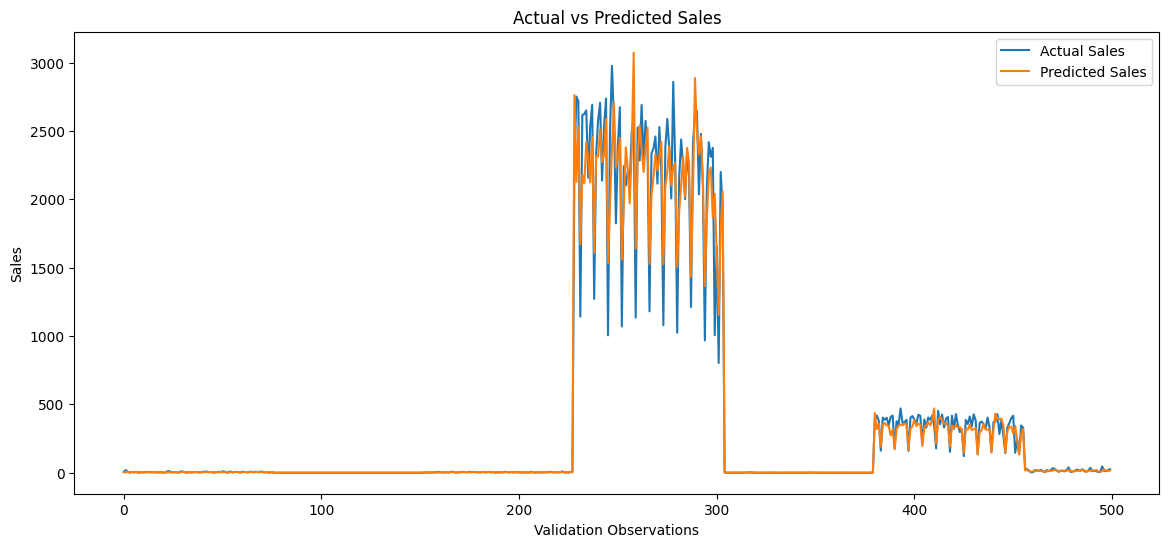

In [117]:
# Create a comparison DataFrame
comparison = pd.DataFrame({
    "actual": y_lag_validation.values,
    "predicted": y_pred
})

# Take the first 500 observations for easier visualization
comparison_sample = comparison.iloc[:500]

plt.figure(figsize=(14, 6))

plt.plot(
    comparison_sample["actual"],
    label="Actual Sales"
)

plt.plot(
    comparison_sample["predicted"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Validation Observations")
plt.ylabel("Sales")
plt.legend()
plt.show()

The comparison between actual and predicted sales shows that the model is generally able to capture the major patterns in sales. The predicted values follow the overall movements of the actual sales, particularly during periods of higher demand. However, some extreme sales peaks are under- or over-predicted, indicating that the model does not capture every short-term fluctuation. Overall, the close alignment between the two series supports the model's performance, which achieved an RMSLE of 0.3931.

In [118]:
# Compare the performance of our forecasting approaches

model_comparison = pd.DataFrame({
    "Model": [
        "Historical Mean Baseline",
        "Initial ML Model",
        "Lag-Feature ML Model"
    ],
    "RMSLE": [
        0.7138,
        1.4568,
        0.3931
    ]
})

model_comparison

,Model,RMSLE
0,Historical Mean Baseline,0.7138
1,Initial ML Model,1.4568
2,Lag-Feature ML Model,0.3931



The model comparison demonstrates the importance of incorporating historical sales informatio.

The initial machine learning model performed worse than the simple historical mean baseline, indicating that the original features were insufficient to capture the temporal behaviour of saes.

After introducing lag and rolling-average features, RMSLE decreased to 03931.

The lag-feature model therefore produced the best validation performance among the three approaches.

In [119]:
# Calculate percentage improvement over the baseline

baseline_rmsle = 0.7138
lag_model_rmsle = 0.3931

improvement = (
    (baseline_rmsle - lag_model_rmsle)
    / baseline_rmsle
) * 100

print("Improvement over baseline:", round(improvement, 2), "%")




Improvement over baseline: 44.93 %



The lag-feature model reduced RMSLE from 0.7138 for the historical mean baseline to 0.393.

This represents an improvement of approximately 44.9% over the baselne.

The result demonstrates that incorporating recent historical sales patterns substantially improves forecasting performance.

In [120]:
# Check the test period
print("Test date range:")
print("Start:", test["date"].min())
print("End:", test["date"].max())

print("\nNumber of test rows:", len(test))

print("\nNumber of stores:", test["store_nbr"].nunique())
print("Number of product families:", test["family"].nunique())



Test date range:
Start: 2017-08-16
End: 2017-08-31

Number of test rows: 28512

Number of stores: 54
Number of product families: 33


In [121]:
# Convert test dates to datetime
test["date"] = pd.to_datetime(test["date"])

# Create calendar features
test["year"] = test["date"].dt.year
test["month"] = test["date"].dt.month
test["day"] = test["date"].dt.day
test["day_of_week_num"] = test["date"].dt.dayofweek

# Identify weekends
test["is_weekend"] = test["day_of_week_num"].isin([5, 6]).astype(int)

# Identify whether products are on promotion
test["is_onpromotion"] = (test["onpromotion"] > 0).astype(int)

# Check the result
test.head()

,id,date,store_nbr,family,onpromotion,year,month,day,day_of_week_num,is_weekend,is_onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0,2017,8,16,2,0,0
1,3000889,2017-08-16,1,BABY CARE,0,2017,8,16,2,0,0
2,3000890,2017-08-16,1,BEAUTY,2,2017,8,16,2,0,1
3,3000891,2017-08-16,1,BEVERAGES,20,2017,8,16,2,0,1
4,3000892,2017-08-16,1,BOOKS,0,2017,8,16,2,0,0


In [122]:
# Add store information to the test dataset
test = test.merge(
    stores,
    on="store_nbr",
    how="left"
)

# Check the result
print("Test shape:", test.shape)
print("\nTest columns:")
print(test.columns.tolist())

print("\nMissing values in store information:")
print(test[["city", "state", "type", "cluster"]].isnull().sum())

Test shape: (28512, 15)

Test columns:
['id', 'date', 'store_nbr', 'family', 'onpromotion', 'year', 'month', 'day', 'day_of_week_num', 'is_weekend', 'is_onpromotion', 'city', 'state', 'type', 'cluster']

Missing values in store information:
city       0
state      0
type       0
cluster    0
dtype: int64


In [123]:
# Add holiday information to the test dataset
holidays["date"] = pd.to_datetime(holidays["date"])

# Create holiday indicators
test["is_holiday"] = test["date"].isin(
    holidays["date"]
).astype(int)

test["is_national_holiday"] = test["date"].isin(
    holidays.loc[holidays["locale"] == "National", "date"]
).astype(int)

test["is_regional_holiday"] = test["date"].isin(
    holidays.loc[holidays["locale"] == "Regional", "date"]
).astype(int)

test["is_local_holiday"] = test["date"].isin(
    holidays.loc[holidays["locale"] == "Local", "date"]
).astype(int)

# Check the result
print("Holiday features added.")

print("\nHoliday counts:")
print(test[
    [
        "is_holiday",
        "is_national_holiday",
        "is_regional_holiday",
        "is_local_holiday"
    ]
].sum())

Holiday features added.

Holiday counts:
is_holiday             1782
is_national_holiday       0
is_regional_holiday       0
is_local_holiday       1782
dtype: int64


In [124]:
# Add oil prices to the test dataset
oil["date"] = pd.to_datetime(oil["date"])

# Keep only date and oil price
test = test.merge(
    oil[["date", "dcoilwtico"]],
    on="date",
    how="left"
)

# Fill missing oil prices using the previous available value
test["dcoilwtico"] = test["dcoilwtico"].ffill()

# Check the result
print("Missing oil prices:", test["dcoilwtico"].isnull().sum())

print("\nOil price summary:")
print(test["dcoilwtico"].describe())

print("\nFirst 5 rows:")
print(test[["date", "dcoilwtico"]].head())

Missing oil prices: 0

Oil price summary:
count    28512.000000
mean        47.462500
std          0.790967
min         45.960000
25%         47.002500
50%         47.520000
75%         47.850000
max         48.590000
Name: dcoilwtico, dtype: float64

First 5 rows:
        date  dcoilwtico
0 2017-08-16        46.8
1 2017-08-16        46.8
2 2017-08-16        46.8
3 2017-08-16        46.8
4 2017-08-16        46.8


In [125]:
# Train the final forecasting model using all available training data
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

final_model.fit(
    X_lag,
    np.log1p(y_lag)
)

print("Final model training completed.")

Final model training completed.


In [126]:
# Prepare historical sales for recursive forecasting
history = train[[
    "date",
    "store_nbr",
    "family",
    "sales"
]].copy()

# Sort the historical data
history = history.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

# Create a date-by-store-family sales table
sales_history = history.pivot(
    index="date",
    columns=["store_nbr", "family"],
    values="sales"
).sort_index()

print("Historical sales table created.")
print("Shape:", sales_history.shape)
print("Last historical date:", sales_history.index.max())

Historical sales table created.
Shape: (1684, 1782)
Last historical date: 2017-08-15 00:00:00


In [127]:
# Prepare the test data for recursive forecasting
forecast_dates = sorted(test["date"].unique())

print("Forecast start:", forecast_dates[0])
print("Forecast end:", forecast_dates[-1])
print("Number of forecast days:", len(forecast_dates))

Forecast start: 2017-08-16 00:00:00
Forecast end: 2017-08-31 00:00:00
Number of forecast days: 16


In [128]:
# Generate recursive forecasts for the test period
forecast_results = []

for forecast_date in forecast_dates:

    # Select all test rows for the current date
    test_day = test[test["date"] == forecast_date].copy()

    # Create lag features using the available sales history
    test_day["lag_1"] = [
        sales_history.loc[forecast_date - pd.Timedelta(days=1), (store, family)]
        for store, family in zip(test_day["store_nbr"], test_day["family"])
    ]

    test_day["lag_7"] = [
        sales_history.loc[forecast_date - pd.Timedelta(days=7), (store, family)]
        for store, family in zip(test_day["store_nbr"], test_day["family"])
    ]

    test_day["lag_14"] = [
        sales_history.loc[forecast_date - pd.Timedelta(days=14), (store, family)]
        for store, family in zip(test_day["store_nbr"], test_day["family"])
    ]

    # Calculate the 7-day rolling mean
    test_day["rolling_mean_7"] = [
        sales_history.loc[
            (sales_history.index >= forecast_date - pd.Timedelta(days=7)) &
            (sales_history.index < forecast_date),
            (store, family)
        ].mean()
        for store, family in zip(test_day["store_nbr"], test_day["family"])
    ]

    # Calculate the 14-day rolling mean
    test_day["rolling_mean_14"] = [
        sales_history.loc[
            (sales_history.index >= forecast_date - pd.Timedelta(days=14)) &
            (sales_history.index < forecast_date),
            (store, family)
        ].mean()
        for store, family in zip(test_day["store_nbr"], test_day["family"])
    ]

    # Prepare features in the same way as the training data
    test_model = pd.get_dummies(
        test_day,
        columns=["family", "type"],
        drop_first=True
    )

    # Keep exactly the same features used by the final model
    test_model = test_model.reindex(
        columns=X_lag.columns,
        fill_value=0
    )

    test_model = test_model.astype(float)

    # Predict on the log scale
    predictions_log = final_model.predict(test_model)

    # Convert predictions back to the original sales scale
    predictions = np.expm1(predictions_log)

    # Prevent negative predictions
    predictions = np.maximum(predictions, 0)

    # Store predictions
    test_day["sales"] = predictions

    forecast_results.append(
        test_day[["id", "date", "store_nbr", "family", "sales"]]
    )

    # Add today's predictions to the history
    # so they can be used for the next forecast day
    for _, row in test_day.iterrows():
        sales_history.loc[
            forecast_date, (row["store_nbr"], row["family"])
        ] = row["sales"]

    print(
        f"Forecasted {forecast_date.date()} | "
        f"Mean sales: {predictions.mean():.2f}"
    )

print("\nRecursive forecasting completed.")

Forecasted 2017-08-16 | Mean sales: 445.29
Forecasted 2017-08-17 | Mean sales: 376.88
Forecasted 2017-08-18 | Mean sales: 428.71
Forecasted 2017-08-19 | Mean sales: 499.92
Forecasted 2017-08-20 | Mean sales: 535.93
Forecasted 2017-08-21 | Mean sales: 420.56
Forecasted 2017-08-22 | Mean sales: 392.14
Forecasted 2017-08-23 | Mean sales: 404.47
Forecasted 2017-08-24 | Mean sales: 362.65
Forecasted 2017-08-25 | Mean sales: 418.20
Forecasted 2017-08-26 | Mean sales: 487.66
Forecasted 2017-08-27 | Mean sales: 517.01
Forecasted 2017-08-28 | Mean sales: 410.12
Forecasted 2017-08-29 | Mean sales: 389.41
Forecasted 2017-08-30 | Mean sales: 417.20
Forecasted 2017-08-31 | Mean sales: 388.86

Recursive forecasting completed.


In [129]:
# Combine all forecast results into one DataFrame
forecast_results = pd.concat(
    forecast_results,
    ignore_index=True
)

print("Forecast results converted to DataFrame successfully.")
print("Shape:", forecast_results.shape)

Forecast results converted to DataFrame successfully.
Shape: (28512, 5)


In [130]:
# Check the final forecast results
print("Forecast results shape:", forecast_results.shape)
print("Expected rows:", len(test))

print("\nNegative predictions:",
      (forecast_results["sales"] < 0).sum())

print("\nForecast summary:")
print(forecast_results["sales"].describe())

print("\nForecast date range:")
print(forecast_results["date"].min(),
      "to",
      forecast_results["date"].max())

Forecast results shape: (28512, 5)
Expected rows: 28512

Negative predictions: 0

Forecast summary:
count    28512.000000
mean       430.936332
std       1158.577028
min          0.000000
25%          3.986042
50%         29.720098
75%        252.459975
max      11907.640052
Name: sales, dtype: float64

Forecast date range:
2017-08-16 00:00:00 to 2017-08-31 00:00:00


In [131]:
submission = test[["id"]].merge(
    forecast_results[["id", "sales"]],
    on="id",
    how="left"
)

print("Submission shape:", submission.shape)
print("Expected shape:", (len(test), 2))

print("\nMissing predictions:")
print(submission["sales"].isna().sum())

print("\nDuplicate IDs:")
print(submission["id"].duplicated().sum())

print("\nSubmission columns:")
print(submission.columns.tolist())

print("\nFirst 5 rows:")
print(submission.head())

Submission shape: (28512, 2)
Expected shape: (28512, 2)

Missing predictions:
0

Duplicate IDs:
0

Submission columns:
['id', 'sales']

First 5 rows:
        id        sales
0  3000888     3.730405
1  3000889     0.041518
2  3000890     4.536305
3  3000891  2062.482271
4  3000892     0.048991


In [132]:
submission.to_csv("submission.csv", index=False)

print("Submission file saved successfully.")
print("File name: submission.csv")

Submission file saved successfully.
File name: submission.csv


In [133]:
daily_forecast = (
    forecast_results
    .groupby("date")["sales"]
    .agg(["sum", "mean"])
    .reset_index()
)

print("Daily forecast summary:")
print(daily_forecast)

Daily forecast summary:
         date            sum        mean
0  2017-08-16  793506.662737  445.289934
1  2017-08-17  671602.693765  376.881422
2  2017-08-18  763953.281967  428.705545
3  2017-08-19  890853.847749  499.917984
4  2017-08-20  955019.914490  535.925878
5  2017-08-21  749430.178581  420.555656
6  2017-08-22  698789.058947  392.137519
7  2017-08-23  720767.817981  404.471278
8  2017-08-24  646234.898044  362.645846
9  2017-08-25  745230.886083  418.199150
10 2017-08-26  869010.126389  487.660004
11 2017-08-27  921309.073294  517.008459
12 2017-08-28  730834.806735  410.120542
13 2017-08-29  693928.154650  389.409739
14 2017-08-30  743444.518618  417.196700
15 2017-08-31  692940.764112  388.855648


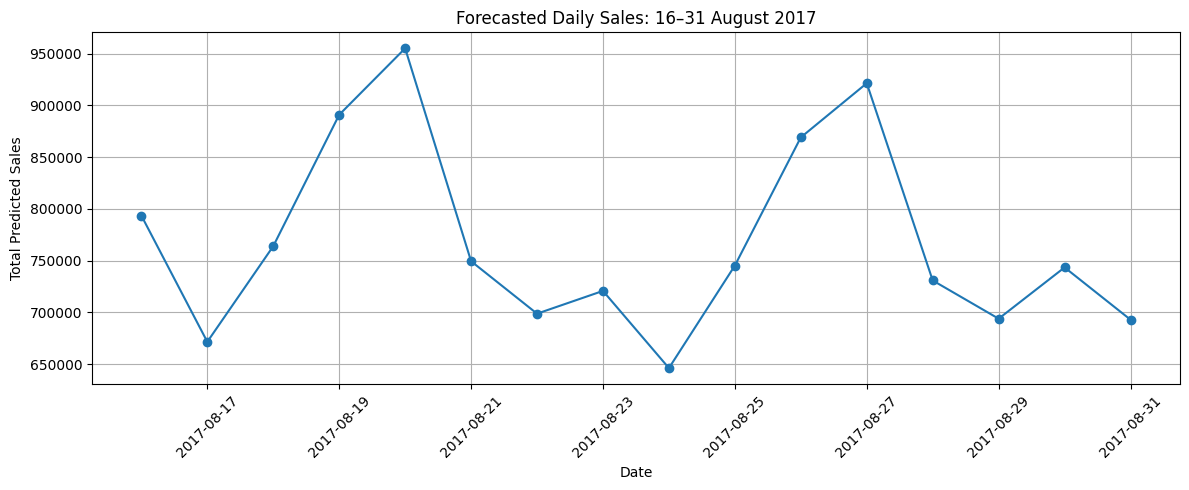

In [134]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_forecast["date"],
    daily_forecast["sum"],
    marker="o"
)

plt.title("Forecasted Daily Sales: 16–31 August 2017")
plt.xlabel("Date")
plt.ylabel("Total Predicted Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [135]:
# Forecast Summary
print("Forecast Period:", daily_forecast["date"].min().date(),
      "to", daily_forecast["date"].max().date())

print("\nTotal Forecasted Sales:",
      daily_forecast["sum"].sum())

print("Average Daily Forecasted Sales:",
      daily_forecast["sum"].mean())

print("Highest Forecasted Sales Day:",
      daily_forecast.loc[daily_forecast["sum"].idxmax(), "date"].date())

print("Highest Forecasted Sales:",
      daily_forecast["sum"].max())

print("Lowest Forecasted Sales Day:",
      daily_forecast.loc[daily_forecast["sum"].idxmin(), "date"].date())

print("Lowest Forecasted Sales:",
      daily_forecast["sum"].min())

Forecast Period: 2017-08-16 to 2017-08-31

Total Forecasted Sales: 12286856.684141956
Average Daily Forecasted Sales: 767928.5427588723
Highest Forecasted Sales Day: 2017-08-20
Highest Forecasted Sales: 955019.9144904235
Lowest Forecasted Sales Day: 2017-08-24
Lowest Forecasted Sales: 646234.8980443539


### Forecast Results

The final forecasting model was used to predict store sales for the period from 16 August 2017 to 31 August 2017.

The model produced a total forecasted sales volume of approximately 12.29 million across all stores and product families during the 16-day forecast period. The average daily forecasted sales were approximately 767,929.

The highest forecasted sales were observed on 20 August 2017, with approximately 955,020 in predicted sales. The lowest forecasted sales occurred on 24 August 2017, with approximately 646,235.

The forecast shows noticeable day-to-day variation and a recurring weekly pattern, with higher predicted sales around weekends. These results provide an estimate of expected sales during the forecast period and can support inventory planning, promotion planning, and resource allocation.

Since the test dataset does not contain actual sales values, the forecast-period predictions cannot be directly evaluated using RMSLE. The model's validation RMSLE of 0.3931 is therefore used as the main measure of predictive performance.

### Model Validation and Forecasting Limitation

The lag-feature model achieved an RMSLE of 0.3931 on the validation dataset. This score represents the model's performance during the validation period using historical sales information.

For the final forecasting period, a recursive forecasting approach was used. Predictions for earlier forecast dates were incorporated into the historical sales table and used to generate subsequent predictions. Therefore, the validation RMSLE of 0.3931 should not be interpreted as the exact expected error for the future forecast period.

The final forecast should therefore be interpreted as an estimate of future sales based on historical patterns, promotions, calendar information, store characteristics, and other available features.

# Business Insights

The analysis and forecasting results provide several important insights into store sales performance.

### 1. Sales show a strong upward trend
Historical sales generally increased over the study period from 2013 to 2017. This indicates growth in overall sales activity and suggests that time-related factors are important when predicting future sales.

### 2. Sales vary substantially across stores
There are significant differences in average sales between stores. Store 44 recorded the highest average sales, while Store 52 recorded the lowest. This suggests that store-specific characteristics and location play an important role in sales performance.

### 3. Store type influences sales
Store Type A had the highest average sales, followed by Types D, B, E, and C. This indicates that different store formats may have different sales capacities and customer demand patterns.

### 4. Product families have different levels of demand
Grocery recorded the highest average sales among the product families, followed by Beverages and Produce. This suggests that demand varies considerably by product category and that inventory planning should consider product-family differences.

### 5. Promotions are associated with higher sales
The correlation between the number of products on promotion and sales was approximately 0.43, indicating a moderate positive relationship. Promotions may therefore contribute to increased sales, although correlation alone does not prove that promotions directly cause higher sales.

### 6. Transactions are strongly associated with sales
Daily transactions had a correlation of approximately 0.68 with sales. This indicates a relatively strong positive relationship between the number of customer transactions and sales. However, transaction data was not included in the final forecasting model because it was unavailable for the test period.

### 7. Sales follow weekly patterns
Sales varied across days of the week, with Sunday and Saturday recording the highest average sales. The forecasting results also showed higher predicted sales around weekends, suggesting that weekly seasonality is important for sales planning.

### 8. Lagged sales are important predictors
The final model showed that recent historical sales were among the most important predictors. The seven-day rolling average, one-day lag, promotion level, and seven-day lag were particularly influential. This demonstrates the importance of previous sales patterns when forecasting future demand.

### 9. The final forecasting model performed better than the baseline
The historical-mean baseline achieved an RMSLE of 0.7138, while the final lag-based model achieved an RMSLE of 0.3931 on the validation period. This represents an improvement of approximately 44.9% over the baseline.

### 10. Forecasted demand remains variable
For 16–31 August 2017, total predicted sales were approximately 12.29 million. The highest predicted daily sales were approximately 955,020 on 20 August, while the lowest were approximately 646,235 on 24 August. This variation suggests that inventory and operational planning should account for changes in expected daily demand.

# Recommendations

Based on the analysis, the following recommendations can be made:

### 1. Use historical sales patterns for inventory planing

The strong importance of lagged sales and rolling averages in the forecasting model suggests that recent sales history should be used when planning inventory. Stores can use recent demand patterns to anticipate future requirements and reduce the risk of stockouts or excess inventory.

### 2. Plan inventory according to produc family

Demand varies substantially across product families. High-demand categories such as Grocery I, Beverages, and Produce should receive greater attention during inventory planning, while lower-demand categories should be managed according to their specific demand patterns.

### 3. Consider store-leveldifferences

Sales performance differs considerably between stores. Management should therefore avoid applying the same inventory and sales strategies to every store. Higher-performing stores may require greater inventory capacity, while lower-performing stores may benefit from strategies aimed at increasing customer demand.

### 4. Use promotios strategically

The analysis found a moderate positive relationship between promotions and sales. Promotions can therefore be considered when planning sales campaigns, particularly for product families or stores where promotional activity is associated with increased demand.

However, promotional decisions should also consider profitability because higher sales do not necessarily mean higher profits.

### 5. Prepare for eekly demand patterns

The analysis showed differences in sales across days of the week, with higher average sales occurring around weekends. Businesses should use these patterns to adjust staffing, inventory levels, and promotional activities according to expected demand.

### 6. Use sales forecass for short-term planning

The final model can provide estimates of expected demand for future dates. The forecast for 16–31 August 2017 predicted approximately 12.29 million in total sales across all store-product combinations. Such forecasts can support short-term inventory, staffing, and operational planning.

### 7. Improve future forecastig with additional information

Future versions of the model could improve the treatment of local and regional holidays by matching each holiday to the geographic location of the affected store. Additional useful variables could also include more detailed promotion information, product-level characteristics, and other external economic factors.

### 8. Continuousy monitor forecasting performance

The model achieved a validation RMSLE of 0.3931, which was approximately 44.9% better than the historical-mean baseline of 0.7138. The model should nevertheless be monitored and retrained periodically as new sales data becomes available, since demand patterns may change over time.

# Conclusion

This project analyzed historical retail sales data and developed a machine learning model to forecast future store sales.

The analysis identified important patterns in sales across time, stores, product families, store types, promotions, and days of the week. Sales showed an overall upward trend, while substantial differences were observed between stores and product families. Weekly patterns were also identified, with higher average sales occurring around weekends.

Promotional activity showed a moderate positive relationship with sales, while transactions showed a stronger positive relationship. However, transactions were not used in the final forecasting model because they were unavailable for the test period.

The final forecasting model incorporated historical sales information through lag and rolling-average features. These features substantially improved predictive performance. The final model achieved a validation RMSLE of 0.3931 compared with 0.7138 for the historical-mean baseline, representing an improvement of approximately 44.9%.

The model was then used to forecast sales for the period from 16 August 2017 to 31 August 2017. The total forecasted sales across all stores and product families were approximately 12.29 million, with an average daily forecast of approximately 767,929.

Overall, the results demonstrate that historical sales patterns, promotions, calendar effects, store characteristics, and product-family information can be useful for retail sales forecasting. The forecasts can support inventory planning, promotion planning, staffing, and other short-term business decisions.

Future work could improve the model by incorporating more detailed geographic holiday effects, additional product and promotion information, and alternative forecasting methods. Since the test period does not contain actual sales values, the final forecasts cannot be directly evaluated against observed outcomes.

### Model Deployment Preparation
The trained forecasting model will be saved so that it can be reused in an interactive application without retraining the model each time. This prepares the model for integration into a Streamlit application.

In [136]:
import joblib

# Save the trained final model
joblib.dump(final_model, "final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


## Save Model Feature Information

The forecasting application must use the same feature structure as the trained model. The feature column names and order used during model training are therefore saved for use during prediction.

In [137]:
# Save the feature columns used by the final model
model_columns = X_lag.columns.tolist()

joblib.dump(model_columns, "model_columns.pkl")

print("Model feature information saved successfully.")
print("Number of features:", len(model_columns))

Model feature information saved successfully.
Number of features: 55


## Prepare Historical Sales Data for Deployment

The forecasting model uses historical sales values to calculate lag and rolling features. The historical sales data will therefore be prepared and saved so that the application can automatically generate these features when making predictions.

In [138]:
# Prepare historical sales data for the application
sales_history_app = train[[
    "date",
    "store_nbr",
    "family",
    "sales"
]].copy()

sales_history_app = sales_history_app.sort_values(
    ["store_nbr", "family", "date"]
).reset_index(drop=True)

print("Historical sales data prepared successfully.")
print("Shape:", sales_history_app.shape)
print("Date range:",
      sales_history_app["date"].min().date(),
      "to",
      sales_history_app["date"].max().date())

Historical sales data prepared successfully.
Shape: (3000888, 4)
Date range: 2013-01-01 to 2017-08-15


## Save Historical Sales Data

The prepared historical sales data will be saved for use by the forecasting application. This allows the application to retrieve previous sales values and calculate the lag and rolling features required by the forecasting model.

In [139]:
# Save historical sales data for the application
sales_history_app.to_csv(
    "sales_history_app.csv",
    index=False
)

print("Historical sales data saved successfully.")
print("File name: sales_history_app.csv")

Historical sales data saved successfully.
File name: sales_history_app.csv


## Save Store Information for Deployment
Store characteristics such as store type, city, state, and cluster are associated with each store number. These details will be saved separately so that the application can automatically retrieve the relevant store information when a user selects a store.

In [140]:
# Save store information for the application
stores.to_csv(
    "stores_app.csv",
    index=False
)

print("Store information saved successfully.")
print("File name: stores_app.csv")
print("Number of stores:", len(stores))

Store information saved successfully.
File name: stores_app.csv
Number of stores: 54


## Save Holiday Information for Deployment
Holiday information is used by the forecasting model to identify whether a given date is associated with a holiday. The holiday dataset will be saved so that the application can automatically generate the required holiday features from a selected forecast date.

In [141]:
# Save holiday information for the application
holidays.to_csv(
    "holidays_app.csv",
    index=False
)

print("Holiday information saved successfully.")
print("File name: holidays_app.csv")
print("Number of holiday records:", len(holidays))

Holiday information saved successfully.
File name: holidays_app.csv
Number of holiday records: 350


## Save Oil Price Information for Deployment

Oil prices are included as a feature in the forecasting model. The oil-price dataset will be saved so that the application can automatically retrieve the relevant oil price for a selected forecast date.

In [142]:
# Save oil price information for the application
oil.to_csv(
    "oil_app.csv",
    index=False
)

print("Oil price information saved successfully.")
print("File name: oil_app.csv")
print("Number of oil price records:", len(oil))

Oil price information saved successfully.
File name: oil_app.csv
Number of oil price records: 1218


## Streamlit Application Setup

The trained forecasting model will be integrated into an interactive Streamlit application. Streamlit will provide a simple interface through which users can enter store, product, date, and promotion information and receive a sales prediction.

In [143]:
!pip install streamlit

## Create the Streamlit Application

The Streamlit application will provide an interactive interface for the retail sales forecasting model. Users will be able to select a store, product family, forecast date, and promotion level, while the application automatically retrieves the remaining information required by the model.

In [172]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib



In [170]:
%%writefile app.py

st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)

st.success("Streamlit application file created successfully.")

Overwriting app.py


## Load the Trained Model and Deployment Data

The Streamlit application will load the trained forecasting model and the supporting data files saved during the deployment preparation stage. This allows the application to make predictions without retraining the model.

In [173]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load the model feature information
model_columns = joblib.load("model_columns.pkl")
 
# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])

st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)

st.success("Model and deployment data loaded successfully.")

Overwriting app.py


## Create the User Input Interface
The application will allow users to select the forecast date, store, product family, and number of products on promotion. Other model features will be generated automatically from the saved datasets and historical sales information.

In [148]:
%%writefile app.py


# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)

st.write("Selected Store:", store_number)
st.write("Selected Product Family:", product_family)
st.write("Selected Promotion Level:", onpromotion)

Overwriting app.py


## Retrieve Store Information Automatically
The store number determines several characteristics used by the forecasting model, including store type and cluster. These values will be retrieved automatically from the saved store dataset rather than requiring the user to enter them manually.

In [149]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information automatically
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Display store information
st.subheader("Store Information")

st.write("Store Type:", store_type)
st.write("Store Cluster:", cluster)

Overwriting app.py


## Generate Date Features Automatically
The forecasting model uses calendar information to capture seasonal and weekly sales patterns. These date features will be generated automatically from the forecast date selected by the user.

In [150]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information automatically
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Generate date features automatically
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])


# Display automatically generated information
st.subheader("Automatically Generated Information")

st.write("Store Type:", store_type)
st.write("Store Cluster:", cluster)
st.write("Year:", year)
st.write("Month:", month)
st.write("Day:", day)
st.write("Day of Week:", day_of_week_num)
st.write("Weekend:", "Yes" if is_weekend else "No")

Overwriting app.py


## Generate Holiday Features Automatically
The forecasting model uses holiday information to capture changes in sales associated with different types of holidays. The application will automatically identify whether the selected forecast date is a holiday and determine its holiday category from the saved holiday dataset.

In [151]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information automatically
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Generate date features automatically
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])


# Generate holiday features automatically
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)


# Display automatically generated information
st.subheader("Automatically Generated Information")

st.write("Store Type:", store_type)
st.write("Store Cluster:", cluster)
st.write("Year:", year)
st.write("Month:", month)
st.write("Day:", day)
st.write("Day of Week:", day_of_week_num)
st.write("Weekend:", "Yes" if is_weekend else "No")
st.write("Holiday:", "Yes" if is_holiday else "No")
st.write("National Holiday:", "Yes" if is_national_holiday else "No")
st.write("Regional Holiday:", "Yes" if is_regional_holiday else "No")
st.write("Local Holiday:", "Yes" if is_local_holiday else "No")

Overwriting app.py


## Retrieve Oil Price Automatically

The forecasting model uses the daily oil price as an economic feature. The application will automatically retrieve the oil price corresponding to the selected forecast date from the saved oil-price dataset.

In [152]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information automatically
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Generate date features automatically
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])


# Generate holiday features automatically
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)


# Retrieve oil price automatically
oil_for_date = oil[
    oil["date"] == forecast_date
]

if not oil_for_date.empty:
    dcoilwtico = oil_for_date["dcoilwtico"].iloc[0]
else:
    previous_oil = oil[
        oil["date"] < forecast_date
    ].sort_values("date")

    if not previous_oil.empty:
        dcoilwtico = previous_oil["dcoilwtico"].iloc[-1]
    else:
        dcoilwtico = oil["dcoilwtico"].median()


# Display automatically generated information
st.subheader("Automatically Generated Information")

st.write("Store Type:", store_type)
st.write("Store Cluster:", cluster)
st.write("Year:", year)
st.write("Month:", month)
st.write("Day:", day)
st.write("Day of Week:", day_of_week_num)
st.write("Weekend:", "Yes" if is_weekend else "No")
st.write("Holiday:", "Yes" if is_holiday else "No")
st.write("National Holiday:", "Yes" if is_national_holiday else "No")
st.write("Regional Holiday:", "Yes" if is_regional_holiday else "No")
st.write("Local Holiday:", "Yes" if is_local_holiday else "No")
st.write("Oil Price:", round(dcoilwtico, 2))

Overwriting app.py


## Calculate Lag and Rolling Sales Features

The forecasting model relies on previous sales values to capture recent demand patterns. The application will automatically retrieve the historical sales for the selected store and product family and calculate the lag and rolling features required by the model.

In [153]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information automatically
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Generate date features automatically
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])


# Generate holiday features automatically
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)


# Retrieve oil price automatically
oil_for_date = oil[
    oil["date"] == forecast_date
]

if not oil_for_date.empty:
    dcoilwtico = oil_for_date["dcoilwtico"].iloc[0]
else:
    previous_oil = oil[
        oil["date"] < forecast_date
    ].sort_values("date")

    if not previous_oil.empty:
        dcoilwtico = previous_oil["dcoilwtico"].iloc[-1]
    else:
        dcoilwtico = oil["dcoilwtico"].median()


# Retrieve historical sales for selected store and family
selected_history = sales_history[
    (sales_history["store_nbr"] == store_number) &
    (sales_history["family"] == product_family) &
    (sales_history["date"] < forecast_date)
].sort_values("date")


# Calculate lag features
if len(selected_history) >= 14:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].iloc[-7]
    lag_14 = selected_history["sales"].iloc[-14]

    rolling_mean_7 = selected_history["sales"].iloc[-7:].mean()
    rolling_mean_14 = selected_history["sales"].iloc[-14:].mean()

else:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].mean()
    lag_14 = selected_history["sales"].mean()

    rolling_mean_7 = selected_history["sales"].mean()
    rolling_mean_14 = selected_history["sales"].mean()


# Display automatically generated information
st.subheader("Automatically Generated Information")

st.write("Store Type:", store_type)
st.write("Store Cluster:", cluster)
st.write("Year:", year)
st.write("Month:", month)
st.write("Day:", day)
st.write("Day of Week:", day_of_week_num)
st.write("Weekend:", "Yes" if is_weekend else "No")
st.write("Holiday:", "Yes" if is_holiday else "No")
st.write("National Holiday:", "Yes" if is_national_holiday else "No")
st.write("Regional Holiday:", "Yes" if is_regional_holiday else "No")
st.write("Local Holiday:", "Yes" if is_local_holiday else "No")
st.write("Oil Price:", round(dcoilwtico, 2))

st.subheader("Historical Sales Features")

st.write("Lag 1:", round(lag_1, 2))
st.write("Lag 7:", round(lag_7, 2))
st.write("Lag 14:", round(lag_14, 2))
st.write("7-Day Rolling Mean:", round(rolling_mean_7, 2))
st.write("14-Day Rolling Mean:", round(rolling_mean_14, 2))

Overwriting app.py


## Prepare the Prediction Input

The automatically generated store, calendar, holiday, oil-price, promotion, and historical sales features will be combined into a single prediction row. The row will then be aligned with the same feature columns used when training the final forecasting model.

In [154]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Generate date features
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])


# Generate holiday features
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)


# Retrieve oil price
oil_for_date = oil[
    oil["date"] == forecast_date
]

if not oil_for_date.empty:
    dcoilwtico = oil_for_date["dcoilwtico"].iloc[0]
else:
    previous_oil = oil[
        oil["date"] < forecast_date
    ].sort_values("date")

    if not previous_oil.empty:
        dcoilwtico = previous_oil["dcoilwtico"].iloc[-1]
    else:
        dcoilwtico = oil["dcoilwtico"].median()


# Retrieve historical sales
selected_history = sales_history[
    (sales_history["store_nbr"] == store_number) &
    (sales_history["family"] == product_family) &
    (sales_history["date"] < forecast_date)
].sort_values("date")


# Calculate lag features
if len(selected_history) >= 14:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].iloc[-7]
    lag_14 = selected_history["sales"].iloc[-14]

    rolling_mean_7 = selected_history["sales"].iloc[-7:].mean()
    rolling_mean_14 = selected_history["sales"].iloc[-14:].mean()

else:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].mean()
    lag_14 = selected_history["sales"].mean()

    rolling_mean_7 = selected_history["sales"].mean()
    rolling_mean_14 = selected_history["sales"].mean()


# Create prediction input
prediction_input = pd.DataFrame({
    "store_nbr": [store_number],
    "family": [product_family],
    "onpromotion": [onpromotion],
    "dcoilwtico": [dcoilwtico],
    "is_holiday": [is_holiday],
    "is_national_holiday": [is_national_holiday],
    "is_regional_holiday": [is_regional_holiday],
    "is_local_holiday": [is_local_holiday],
    "year": [year],
    "month": [month],
    "day": [day],
    "day_of_week_num": [day_of_week_num],
    "is_weekend": [is_weekend],
    "type": [store_type],
    "cluster": [cluster],
    "lag_1": [lag_1],
    "lag_7": [lag_7],
    "lag_14": [lag_14],
    "rolling_mean_7": [rolling_mean_7],
    "rolling_mean_14": [rolling_mean_14]
})


# Convert categorical variables into dummy variables
prediction_input = pd.get_dummies(
    prediction_input,
    columns=["family", "type"],
    drop_first=True
)


# Match the model's 55 training features
prediction_input = prediction_input.reindex(
    columns=model_columns,
    fill_value=0
)


# Convert all features to numeric format
prediction_input = prediction_input.astype(float)


st.subheader("Prediction Input Prepared")

st.write(
    "Number of model features:",
    prediction_input.shape[1]
)

Overwriting app.py


## Generate Sales Prediction

The prepared prediction input will be passed to the trained forecasting model. Since the model was trained using log-transformed sales, the predicted value will be converted back to the original sales scale before being displayed to the user.

In [155]:
%%writefile app.py
# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])


# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)


# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)


# Retrieve store information
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]


# Generate date features
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])


# Generate holiday features
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)


# Retrieve oil price
oil_for_date = oil[
    oil["date"] == forecast_date
]

if not oil_for_date.empty:
    dcoilwtico = oil_for_date["dcoilwtico"].iloc[0]
else:
    previous_oil = oil[
        oil["date"] < forecast_date
    ].sort_values("date")

    if not previous_oil.empty:
        dcoilwtico = previous_oil["dcoilwtico"].iloc[-1]
    else:
        dcoilwtico = oil["dcoilwtico"].median()


# Retrieve historical sales
selected_history = sales_history[
    (sales_history["store_nbr"] == store_number) &
    (sales_history["family"] == product_family) &
    (sales_history["date"] < forecast_date)
].sort_values("date")


# Calculate lag features
if len(selected_history) >= 14:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].iloc[-7]
    lag_14 = selected_history["sales"].iloc[-14]

    rolling_mean_7 = selected_history["sales"].iloc[-7:].mean()
    rolling_mean_14 = selected_history["sales"].iloc[-14:].mean()

else:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].mean()
    lag_14 = selected_history["sales"].mean()

    rolling_mean_7 = selected_history["sales"].mean()
    rolling_mean_14 = selected_history["sales"].mean()


# Create prediction input
prediction_input = pd.DataFrame({
    "store_nbr": [store_number],
    "family": [product_family],
    "onpromotion": [onpromotion],
    "dcoilwtico": [dcoilwtico],
    "is_holiday": [is_holiday],
    "is_national_holiday": [is_national_holiday],
    "is_regional_holiday": [is_regional_holiday],
    "is_local_holiday": [is_local_holiday],
    "year": [year],
    "month": [month],
    "day": [day],
    "day_of_week_num": [day_of_week_num],
    "is_weekend": [is_weekend],
    "type": [store_type],
    "cluster": [cluster],
    "lag_1": [lag_1],
    "lag_7": [lag_7],
    "lag_14": [lag_14],
    "rolling_mean_7": [rolling_mean_7],
    "rolling_mean_14": [rolling_mean_14]
})


# Convert categorical variables into dummy variables
prediction_input = pd.get_dummies(
    prediction_input,
    columns=["family", "type"],
    drop_first=True
)


# Match the model's training features
prediction_input = prediction_input.reindex(
    columns=model_columns,
    fill_value=0
)

# Convert features to numeric format
prediction_input = prediction_input.astype(float)


# Generate prediction
if st.button("Predict Sales"):

    prediction_log = model.predict(prediction_input)

    prediction = np.expm1(prediction_log)

    prediction = max(float(prediction[0]), 0)

    st.subheader("Predicted Sales")

    st.metric(
        label="Estimated Sales",
        value=f"{prediction:,.2f}"
    )

    st.info(
        "This is an estimated sales value generated by the "
        "trained forecasting model."
    )

Overwriting app.py


## Generate Sales Prediction
The prepared prediction input will now be passed to the trained forecasting model. Since the model was trained using the logarithm of sales, the prediction will be transformed back to the original sales scale before being displayed to the user.

In [156]:
%%writefile app.py
# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])

# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)

# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)

# Retrieve store information
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]

# Generate date features
forecast_date = pd.to_datetime(forecast_date)

year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])

# Generate holiday features
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)

# Retrieve oil price
oil_for_date = oil[
    oil["date"] == forecast_date
]

if not oil_for_date.empty:
    dcoilwtico = oil_for_date["dcoilwtico"].iloc[0]
else:
    previous_oil = oil[
        oil["date"] < forecast_date
    ].sort_values("date")

    if not previous_oil.empty:
        dcoilwtico = previous_oil["dcoilwtico"].iloc[-1]
    else:
        dcoilwtico = oil["dcoilwtico"].median()

# Retrieve historical sales
selected_history = sales_history[
    (sales_history["store_nbr"] == store_number) &
    (sales_history["family"] == product_family) &
    (sales_history["date"] < forecast_date)
].sort_values("date")

# Calculate lag features
if len(selected_history) >= 14:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].iloc[-7]
    lag_14 = selected_history["sales"].iloc[-14]

    rolling_mean_7 = selected_history["sales"].iloc[-7:].mean()
    rolling_mean_14 = selected_history["sales"].iloc[-14:].mean()

else:

    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].mean()
    lag_14 = selected_history["sales"].mean()

    rolling_mean_7 = selected_history["sales"].mean()
    rolling_mean_14 = selected_history["sales"].mean()

# Create prediction input
prediction_input = pd.DataFrame({
    "store_nbr": [store_number],
    "family": [product_family],
    "onpromotion": [onpromotion],
    "dcoilwtico": [dcoilwtico],
    "is_holiday": [is_holiday],
    "is_national_holiday": [is_national_holiday],
    "is_regional_holiday": [is_regional_holiday],
    "is_local_holiday": [is_local_holiday],
    "year": [year],
    "month": [month],
    "day": [day],
    "day_of_week_num": [day_of_week_num],
    "is_weekend": [is_weekend],
    "type": [store_type],
    "cluster": [cluster],
    "lag_1": [lag_1],
    "lag_7": [lag_7],
    "lag_14": [lag_14],
    "rolling_mean_7": [rolling_mean_7],
    "rolling_mean_14": [rolling_mean_14]
})

# Convert categorical variables into dummy variables
prediction_input = pd.get_dummies(
    prediction_input,
    columns=["family", "type"],
    drop_first=True
)

# Match the model's training features
prediction_input = prediction_input.reindex(
    columns=model_columns,
    fill_value=0
)

# Convert all features to numeric format
prediction_input = prediction_input.astype(float)

# Generate prediction
st.subheader("Sales Prediction")

if st.button("Predict Sales"):

    prediction_log = model.predict(prediction_input)

    # Convert prediction back from logarithmic scale
    prediction = np.expm1(prediction_log)

    # Prevent negative predictions
    prediction = max(float(prediction[0]), 0)

    st.metric(
        label="Estimated Sales",
        value=f"{prediction:,.2f}"
    )

    st.info(
        "This is an estimated sales value generated by the trained forecasting model."
    )

Overwriting app.py


## Validate the Forecast Date
The forecasting model was developed using historical data ending on 15 August 2017, with the original forecasting period covering 16 to 31 August 2017. The application will therefore validate the selected date before calculating the historical sales features.

In [157]:
%%writefile app.py

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])

# Application title
st.title("Retail Sales Forecasting App")

st.write(
    "Use this application to estimate future retail sales "
    "for a selected store and product family."
)

# User inputs
st.subheader("Enter Forecast Information")

forecast_date = st.date_input(
    "Forecast Date",
    value=pd.to_datetime("2017-08-16"),
    min_value=pd.to_datetime("2017-08-16"),
    max_value=pd.to_datetime("2017-08-31")
)

store_number = st.selectbox(
    "Store Number",
    sorted(stores["store_nbr"].unique())
)

product_family = st.selectbox(
    "Product Family",
    sorted(sales_history["family"].unique())
)

onpromotion = st.number_input(
    "Number of Products on Promotion",
    min_value=0,
    value=0,
    step=1
)

# Convert date
forecast_date = pd.to_datetime(forecast_date)

# Retrieve store information
selected_store = stores[
    stores["store_nbr"] == store_number
].iloc[0]

store_type = selected_store["type"]
cluster = selected_store["cluster"]

# Generate date features
year = forecast_date.year
month = forecast_date.month
day = forecast_date.day
day_of_week_num = forecast_date.dayofweek
is_weekend = int(day_of_week_num in [5, 6])

# Generate holiday features
is_holiday = int(
    forecast_date in holidays["date"].values
)

is_national_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "National", "date"
    ].values
)

is_regional_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Regional", "date"
    ].values
)

is_local_holiday = int(
    forecast_date in holidays.loc[
        holidays["locale"] == "Local", "date"
    ].values
)

# Retrieve oil price
oil_for_date = oil[
    oil["date"] == forecast_date
]

if not oil_for_date.empty:
    dcoilwtico = oil_for_date["dcoilwtico"].iloc[0]
else:
    previous_oil = oil[
        oil["date"] < forecast_date
    ].sort_values("date")

    if not previous_oil.empty:
        dcoilwtico = previous_oil["dcoilwtico"].iloc[-1]
    else:
        dcoilwtico = oil["dcoilwtico"].median()

# Retrieve historical sales
selected_history = sales_history[
    (sales_history["store_nbr"] == store_number) &
    (sales_history["family"] == product_family) &
    (sales_history["date"] < forecast_date)
].sort_values("date")

# Check that sufficient historical data exists
if len(selected_history) < 14:

    st.error(
        "There is not enough historical sales data to calculate "
        "the required lag features."
    )

else:

    # Calculate lag features
    lag_1 = selected_history["sales"].iloc[-1]
    lag_7 = selected_history["sales"].iloc[-7]
    lag_14 = selected_history["sales"].iloc[-14]

    rolling_mean_7 = selected_history["sales"].iloc[-7:].mean()
    rolling_mean_14 = selected_history["sales"].iloc[-14:].mean()

    # Create prediction input
    prediction_input = pd.DataFrame({
        "store_nbr": [store_number],
        "family": [product_family],
        "onpromotion": [onpromotion],
        "dcoilwtico": [dcoilwtico],
        "is_holiday": [is_holiday],
        "is_national_holiday": [is_national_holiday],
        "is_regional_holiday": [is_regional_holiday],
        "is_local_holiday": [is_local_holiday],
        "year": [year],
        "month": [month],
        "day": [day],
        "day_of_week_num": [day_of_week_num],
        "is_weekend": [is_weekend],
        "type": [store_type],
        "cluster": [cluster],
        "lag_1": [lag_1],
        "lag_7": [lag_7],
        "lag_14": [lag_14],
        "rolling_mean_7": [rolling_mean_7],
        "rolling_mean_14": [rolling_mean_14]
    })

    # Convert categorical variables into dummy variables
    prediction_input = pd.get_dummies(
        prediction_input,
        columns=["family", "type"],
        drop_first=True
    )

    # Match the model's training features
    prediction_input = prediction_input.reindex(
        columns=model_columns,
        fill_value=0
    )

    # Convert features to numeric format
    prediction_input = prediction_input.astype(float)

    # Prediction button
    st.subheader("Sales Prediction")

    if st.button("Predict Sales"):

        prediction_log = model.predict(prediction_input)

        # Convert prediction back from logarithmic scale
        prediction = np.expm1(prediction_log)

        # Prevent negative predictions
        prediction = max(float(prediction[0]), 0)

        st.metric(
            label="Estimated Sales",
            value=f"{prediction:,.2f}"
        )

        st.info(
            "This is an estimated sales value generated by "
            "the trained forecasting model."
        )

Overwriting app.py


In [175]:
app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Load the trained model
model = joblib.load("final_model.pkl")

# Load model feature information
model_columns = joblib.load("model_columns.pkl")

# Load historical sales data
sales_history = pd.read_csv("sales_history_app.csv")
sales_history["date"] = pd.to_datetime(sales_history["date"])

# Load store information
stores = pd.read_csv("stores_app.csv")

# Load holiday information
holidays = pd.read_csv("holidays_app.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

# Load oil price information
oil = pd.read_csv("oil_app.csv")
oil["date"] = pd.to_datetime(oil["date"])

# Application title
st.title("Retail Sales Forecasting App")

# ...rest of application...
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


## Run the Streamlit Application
The Streamlit application will now be launched to test the interactive forecasting interface and verify that the trained model can generate sales predictions from user-selected inputs.

In [176]:
import sys

!{sys.executable} -m pip install --upgrade streamlit


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\wangu\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [177]:
!{sys.executable} -m streamlit version

Streamlit, version 1.64.0


In [178]:
import os

print("app.py exists:", os.path.exists("app.py"))
print("Model exists:", os.path.exists("final_model.pkl"))
print("Model columns exists:", os.path.exists("model_columns.pkl"))
print("Sales history exists:", os.path.exists("sales_history_app.csv"))
print("Stores exists:", os.path.exists("stores_app.csv"))
print("Holidays exists:", os.path.exists("holidays_app.csv"))
print("Oil exists:", os.path.exists("oil_app.csv"))

app.py exists: True
Model exists: True
Model columns exists: True
Sales history exists: True
Stores exists: True
Holidays exists: True
Oil exists: True


In [179]:
print("sales_history_app.csv size:",
      round(os.path.getsize("sales_history_app.csv") / (1024**2), 2),
      "MB")

sales_history_app.csv size: 91.28 MB


In [180]:
import time

start_time = time.time()

test_history = pd.read_csv("sales_history_app.csv")
test_history["date"] = pd.to_datetime(test_history["date"])

end_time = time.time()

print("File loaded successfully.")
print("Shape:", test_history.shape)
print("Loading time:", round(end_time - start_time, 2), "seconds")

File loaded successfully.
Shape: (3000888, 4)
Loading time: 3.4 seconds


In [181]:
import ast

with open("app.py", "r", encoding="utf-8") as f:
    app_code = f.read()

ast.parse(app_code)

print("app.py syntax check: PASSED")

app.py syntax check: PASSED


In [182]:
import subprocess

start_time = time.time()

process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(10)

print("Streamlit process started:", process.poll() is None)
print("Startup time checked after:", round(time.time() - start_time, 2), "seconds")

process.terminate()

Streamlit process started: True
Startup time checked after: 10.01 seconds


In [183]:
#Finding the steamlit startup error
process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

try:
    output, _ = process.communicate(timeout=15)
except subprocess.TimeoutExpired:
    process.terminate()
    output, _ = process.communicate()

print(output)

2026-09-22 07:45:57.252 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.26.179.61:8501

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.




In [184]:
streamlit_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.headless=true",
        "--browser.gatherUsageStats=false"
    ],
    creationflags=subprocess.CREATE_NEW_CONSOLE
)

print("Streamlit has been launched.")
print("Open this address in your browser:")
print("http://localhost:8501")

Streamlit has been launched.
Open this address in your browser:
http://localhost:8501
